In [1]:
# ============================================================================
# NOTEBOOK 03: MODEL TRAINING AND EVALUATION
# KDHS ECD Delay Prediction Project
# ============================================================================
"""
Study Scope: Children aged 36-59 months only
Methodology: UNICEF ECDI2030 (SDG Indicator 4.2.1 Compliant)

This notebook:
1. Loads prepared training/test data from Notebook 02
2. Trains multiple baseline models
3. Trains ensemble models
4. Performs stratified cross-validation
5. Handles class imbalance
6. Tunes major models with Optuna
7. Compares all baseline and tuned models
8. Builds tuned ensembles from strongest tuned models
9. Selects best model for deployment
10. Generates evaluation plots for dissertation
11. Saves best models and API assets for Flask
"""

# ============================================================================
# IMPORTS AND SETUP
# ============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import sys
import joblib
import json
import warnings
import re
from datetime import datetime

from sklearn.base import clone
from sklearn.model_selection import (
    cross_val_score,
    StratifiedKFold,
    learning_curve
)
from sklearn.metrics import (
    roc_auc_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    precision_recall_curve,
    average_precision_score,
    brier_score_loss
)
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
    VotingClassifier,
    StackingClassifier,
    BaggingClassifier,
    AdaBoostClassifier,
    ExtraTreesClassifier
)
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.calibration import calibration_curve
from sklearn.inspection import permutation_importance

import optuna
from optuna.samplers import TPESampler

warnings.filterwarnings("ignore")

/Users/collinsbiwott/Desktop/ecd_final_ml/venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Add src to path
sys.path.insert(0, str(Path.cwd().parent.parent))
from src.data import get_data_paths, DOMAIN_ITEMS

# Configure plots for dissertation
plt.rcParams["figure.figsize"] = [10, 6]
plt.rcParams["figure.dpi"] = 300
plt.rcParams["savefig.dpi"] = 300
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
plt.rcParams["font.size"] = 11
plt.rcParams["font.family"] = "serif"
plt.rcParams["pdf.fonttype"] = 42

print("Imports successful")
print(f"Python version: {sys.version.split()[0]}")
print(f"Scikit-learn version: {__import__('sklearn').__version__}")
print(f"Optuna version: {optuna.__version__}")

# Get paths
paths = get_data_paths()

print(f"\nProject Root: {paths['root']}")
print(f"Processed Data: {paths['processed']}")
print(f"Models: {paths['models']}")
print(f"Reports: {paths['reports']}")

# Output directories
dissertation_dir = paths["reports"] / "dissertation"
dissertation_dir.mkdir(parents=True, exist_ok=True)
(dissertation_dir / "figures").mkdir(exist_ok=True)
(dissertation_dir / "tables").mkdir(exist_ok=True)
(dissertation_dir / "latex_snippets").mkdir(exist_ok=True)

tables_dir = paths.get("tables", dissertation_dir / "tables")
Path(tables_dir).mkdir(parents=True, exist_ok=True)

print(f"Output directory: {dissertation_dir}")

Imports successful
Python version: 3.10.14
Scikit-learn version: 1.3.2
Optuna version: 3.4.0

Project Root: /Users/collinsbiwott/Desktop/ecd_final_ml
Processed Data: /Users/collinsbiwott/Desktop/ecd_final_ml/data/processed
Models: /Users/collinsbiwott/Desktop/ecd_final_ml/models
Reports: /Users/collinsbiwott/Desktop/ecd_final_ml/reports
Output directory: /Users/collinsbiwott/Desktop/ecd_final_ml/reports/dissertation


In [3]:
# ============================================================================
# LOAD TRAINING AND TEST DATA
# ============================================================================

print("\nLoading Training and Test Data")
print("=" * 70)

# Load features
X_train = pd.read_parquet(paths["processed"] / "X_train.parquet")
X_test = pd.read_parquet(paths["processed"] / "X_test.parquet")

# Load composite target
y_train_df = pd.read_parquet(paths["processed"] / "y_train.parquet")
y_test_df = pd.read_parquet(paths["processed"] / "y_test.parquet")
y_train = y_train_df["ecd_delay_composite"]
y_test = y_test_df["ecd_delay_composite"]

# Load domain targets
y_domains_train = {}
y_domains_test = {}

for domain in DOMAIN_ITEMS.keys():
    y_train_domain = pd.read_parquet(paths["processed"] / f"y_train_{domain}.parquet")
    y_test_domain = pd.read_parquet(paths["processed"] / f"y_test_{domain}.parquet")
    y_domains_train[domain] = y_train_domain[f"{domain}_delay"]
    y_domains_test[domain] = y_test_domain[f"{domain}_delay"]

print(f"Training data: X={X_train.shape}, y={y_train.shape}")
print(f"Test data: X={X_test.shape}, y={y_test.shape}")
print(f"Domain targets: {list(y_domains_train.keys())}")

# Load metadata
with open(paths["processed"] / "dataset_metadata.json", "r") as f:
    metadata = json.load(f)

print("\nDataset Info:")
print(f"   Study scope: {metadata['study_scope']}")
print(f"   Methodology: {metadata['methodology']}")
print(f"   Features: {metadata['n_features']}")
print(f"   Train delay rate: {metadata['delay_rate_train']:.2%}")
print(f"   Test delay rate: {metadata['delay_rate_test']:.2%}")

print("\nClass Distribution (Composite Target):")
print(f"   Train - On Track: {(y_train == 0).sum()} ({(y_train == 0).mean():.1%})")
print(f"   Train - Delayed:  {(y_train == 1).sum()} ({(y_train == 1).mean():.1%})")
print(f"   Imbalance Ratio: {(y_train == 0).sum() / (y_train == 1).sum():.2f}:1")



Loading Training and Test Data
Training data: X=(2879, 16), y=(2879,)
Test data: X=(720, 16), y=(720,)
Domain targets: ['physical', 'language', 'literacy', 'socio_emotional']

Dataset Info:
   Study scope: 36-59 months
   Methodology: UNICEF ECDI2030 (SDG 4.2.1)
   Features: 16
   Train delay rate: 49.29%
   Test delay rate: 49.31%

Class Distribution (Composite Target):
   Train - On Track: 1460 (50.7%)
   Train - Delayed:  1419 (49.3%)
   Imbalance Ratio: 1.03:1


In [4]:
# ============================================================================
# PREPARE SCALED FEATURES
# ============================================================================

print("\nPreparing Scaled Features")
print("=" * 70)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

joblib.dump(scaler, paths["models"] / "feature_scaler.pkl")
print("Saved feature scaler")



Preparing Scaled Features
Saved feature scaler


In [5]:
# ============================================================================
# CLEAN FEATURE NAMES
# ============================================================================

print("\nCleaning Feature Names")
print("=" * 70)

def clean_feature_names(columns):
    cleaned = []
    for col in columns:
        col = re.sub(r"(_encoded|_scaled|_imputed)$", "", col)
        cleaned.append(col)
    return cleaned

feature_names_clean = clean_feature_names(X_train.columns)
print(f"Number of cleaned feature names: {len(feature_names_clean)}")


Cleaning Feature Names
Number of cleaned feature names: 16


In [6]:
# ============================================================================
# DEFINE MODELS
# ============================================================================

print("\nDefining Models")
print("=" * 70)

scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

INDIVIDUAL_MODELS = {
    "Logistic Regression": LogisticRegression(
        max_iter=2000,
        random_state=42,
        class_weight="balanced",
        solver="lbfgs"
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        max_depth=10,
        random_state=42,
        class_weight="balanced",
        n_jobs=-1
    ),
    "XGBoost": __import__("xgboost").XGBClassifier(
        n_estimators=200,
        max_depth=6,
        learning_rate=0.05,
        random_state=42,
        use_label_encoder=False,
        eval_metric="logloss",
        scale_pos_weight=scale_pos_weight,
        verbosity=0
    ),
    "LightGBM": __import__("lightgbm").LGBMClassifier(
        n_estimators=200,
        max_depth=6,
        learning_rate=0.05,
        num_leaves=31,
        random_state=42,
        class_weight="balanced",
        n_jobs=-1,
        verbose=-1,
        force_col_wise=True
    ),
    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=200,
        learning_rate=0.05,
        random_state=42
    ),
    "Extra Trees": ExtraTreesClassifier(
        n_estimators=200,
        max_depth=10,
        random_state=42,
        class_weight="balanced",
        n_jobs=-1
    ),
    "AdaBoost": AdaBoostClassifier(
        estimator=DecisionTreeClassifier(max_depth=1, random_state=42),
        n_estimators=100,
        learning_rate=0.1,
        random_state=42
    ),
    "SVC": SVC(
        C=1.0,
        kernel="rbf",
        probability=True,
        class_weight="balanced",
        random_state=42
    )
}

print(f"Individual models defined: {list(INDIVIDUAL_MODELS.keys())}")



Defining Models


Individual models defined: ['Logistic Regression', 'Random Forest', 'XGBoost', 'LightGBM', 'Gradient Boosting', 'Extra Trees', 'AdaBoost', 'SVC']


In [7]:
ENSEMBLE_MODELS = {
    "Voting (Soft)": VotingClassifier(
        estimators=[
            ("rf", clone(INDIVIDUAL_MODELS["Random Forest"])),
            ("xgb", clone(INDIVIDUAL_MODELS["XGBoost"])),
            ("lgbm", clone(INDIVIDUAL_MODELS["LightGBM"]))
        ],
        voting="soft",
        n_jobs=-1
    ),
    "Voting (Hard)": VotingClassifier(
        estimators=[
            ("rf", clone(INDIVIDUAL_MODELS["Random Forest"])),
            ("xgb", clone(INDIVIDUAL_MODELS["XGBoost"])),
            ("lgbm", clone(INDIVIDUAL_MODELS["LightGBM"]))
        ],
        voting="hard",
        n_jobs=-1
    ),
    "Stacking (LR Meta)": StackingClassifier(
        estimators=[
            ("rf", clone(INDIVIDUAL_MODELS["Random Forest"])),
            ("xgb", clone(INDIVIDUAL_MODELS["XGBoost"])),
            ("lgbm", clone(INDIVIDUAL_MODELS["LightGBM"]))
        ],
        final_estimator=LogisticRegression(
            max_iter=2000,
            class_weight="balanced",
            random_state=42
        ),
        cv=5,
        n_jobs=-1
    ),
    "Stacking (XGB Meta)": StackingClassifier(
        estimators=[
            ("rf", clone(INDIVIDUAL_MODELS["Random Forest"])),
            ("xgb", clone(INDIVIDUAL_MODELS["XGBoost"])),
            ("lgbm", clone(INDIVIDUAL_MODELS["LightGBM"]))
        ],
        final_estimator=__import__("xgboost").XGBClassifier(
            n_estimators=50,
            max_depth=3,
            random_state=42,
            use_label_encoder=False,
            eval_metric="logloss",
            verbosity=0
        ),
        cv=5,
        n_jobs=-1
    ),
    "Bagging (RF Base)": BaggingClassifier(
        estimator=clone(INDIVIDUAL_MODELS["Random Forest"]),
        n_estimators=10,
        max_samples=0.8,
        max_features=0.8,
        bootstrap=True,
        random_state=42,
        n_jobs=-1
    )
}

print(f"Ensemble models defined: {list(ENSEMBLE_MODELS.keys())}")

Ensemble models defined: ['Voting (Soft)', 'Voting (Hard)', 'Stacking (LR Meta)', 'Stacking (XGB Meta)', 'Bagging (RF Base)']


In [8]:
# ============================================================================
# HELPER FUNCTIONS
# ============================================================================

print("\nDefining Helper Functions")
print("=" * 70)

cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

def uses_scaled_features(model_name):
    return model_name in [
        "Logistic Regression",
        "SVC",
        "Tuned Logistic Regression",
        "Tuned SVC"
    ]

def get_train_test_for_model(model_name):
    if uses_scaled_features(model_name):
        return X_train_scaled, X_test_scaled
    return X_train, X_test

def get_model_scores(model, X):
    if hasattr(model, "predict_proba"):
        try:
            return model.predict_proba(X)[:, 1]
        except Exception:
            pass

    if hasattr(model, "decision_function"):
        try:
            return model.decision_function(X)
        except Exception:
            pass

    return None

def normalize_scores_for_plot(scores):
    if scores is None:
        return None

    scores = np.asarray(scores)

    if np.min(scores) < 0 or np.max(scores) > 1:
        scores = (scores - scores.min()) / (scores.max() - scores.min() + 1e-12)

    return scores

def evaluate_model(model, X_train_use, y_train, X_test_use, y_test, model_name="", cv_folds=5):
    """
    Safe evaluation for all models, including hard voting.
    """
    results = {}

    model.fit(X_train_use, y_train)
    y_pred = model.predict(X_test_use)
    y_score = get_model_scores(model, X_test_use)

    results["accuracy"] = float(accuracy_score(y_test, y_pred))
    results["precision"] = float(precision_score(y_test, y_pred, zero_division=0))
    results["recall"] = float(recall_score(y_test, y_pred, zero_division=0))
    results["f1"] = float(f1_score(y_test, y_pred, zero_division=0))

    if y_score is not None and len(np.unique(y_test)) > 1:
        y_score_plot = normalize_scores_for_plot(y_score)
        results["roc_auc"] = float(roc_auc_score(y_test, y_score_plot))
        results["avg_precision"] = float(average_precision_score(y_test, y_score_plot))
    else:
        results["roc_auc"] = np.nan
        results["avg_precision"] = np.nan

    cv = StratifiedKFold(n_splits=cv_folds, shuffle=True, random_state=42)

    if hasattr(model, "predict_proba") or hasattr(model, "decision_function"):
        try:
            cv_scores = cross_val_score(
                model,
                X_train_use,
                y_train,
                cv=cv,
                scoring="roc_auc",
                n_jobs=-1
            )
            results["cv_roc_auc_mean"] = float(cv_scores.mean())
            results["cv_roc_auc_std"] = float(cv_scores.std())
            results["cv_fold_scores"] = cv_scores.tolist()
        except Exception:
            results["cv_roc_auc_mean"] = np.nan
            results["cv_roc_auc_std"] = np.nan
            results["cv_fold_scores"] = []
    else:
        results["cv_roc_auc_mean"] = np.nan
        results["cv_roc_auc_std"] = np.nan
        results["cv_fold_scores"] = []

    results["confusion_matrix"] = confusion_matrix(y_test, y_pred).tolist()
    results["model_name"] = model_name

    return results

def summarize_results(results, label="Model"):
    if np.isnan(results["cv_roc_auc_mean"]):
        if np.isnan(results["roc_auc"]):
            print(f"   {label} ROC-AUC: Not available")
        else:
            print(f"   {label} ROC-AUC: {results['roc_auc']:.4f} (CV: Not available)")
    else:
        print(
            f"   {label} ROC-AUC: {results['roc_auc']:.4f} "
            f"(CV: {results['cv_roc_auc_mean']:.4f} +/- {results['cv_roc_auc_std']:.4f})"
        )

    print(f"   {label} F1-Score: {results['f1']:.4f}")

def save_dataframe(df, filename):
    csv_path = Path(tables_dir) / filename
    df.to_csv(csv_path, index=False)
    print(f"Saved: {csv_path}")

print("Helper functions defined")



Defining Helper Functions
Helper functions defined


In [9]:
# ============================================================================
# TRAIN BASELINE INDIVIDUAL MODELS
# ============================================================================

print("\nTraining Baseline Individual Models")
print("=" * 70)

individual_results = {}

for model_name, model in INDIVIDUAL_MODELS.items():
    print(f"\nTraining {model_name}...")

    X_train_use, X_test_use = get_train_test_for_model(model_name)

    results = evaluate_model(
        clone(model),
        X_train_use, y_train,
        X_test_use, y_test,
        model_name=model_name,
        cv_folds=5
    )

    individual_results[model_name] = results
    summarize_results(results)

print("\nBaseline individual model training complete")


Training Baseline Individual Models

Training Logistic Regression...
   Model ROC-AUC: 0.7140 (CV: 0.6829 +/- 0.0208)
   Model F1-Score: 0.6594

Training Random Forest...
   Model ROC-AUC: 0.7657 (CV: 0.7454 +/- 0.0146)
   Model F1-Score: 0.6890

Training XGBoost...
   Model ROC-AUC: 0.7396 (CV: 0.7448 +/- 0.0152)
   Model F1-Score: 0.6705

Training LightGBM...
   Model ROC-AUC: 0.7506 (CV: 0.7470 +/- 0.0122)
   Model F1-Score: 0.6892

Training Gradient Boosting...
   Model ROC-AUC: 0.7627 (CV: 0.7575 +/- 0.0186)
   Model F1-Score: 0.7009

Training Extra Trees...
   Model ROC-AUC: 0.7609 (CV: 0.7392 +/- 0.0190)
   Model F1-Score: 0.6820

Training AdaBoost...
   Model ROC-AUC: 0.7591 (CV: 0.7351 +/- 0.0119)
   Model F1-Score: 0.6804

Training SVC...
   Model ROC-AUC: 0.7363 (CV: 0.7101 +/- 0.0238)
   Model F1-Score: 0.6781

Baseline individual model training complete


In [10]:
# ============================================================================
# TRAIN BASELINE ENSEMBLE MODELS
# ============================================================================

print("\nTraining Baseline Ensemble Models")
print("=" * 70)

ensemble_results = {}

for model_name, model in ENSEMBLE_MODELS.items():
    print(f"\nTraining {model_name}...")

    try:
        X_train_use, X_test_use = get_train_test_for_model(model_name)

        results = evaluate_model(
            clone(model),
            X_train_use, y_train,
            X_test_use, y_test,
            model_name=model_name,
            cv_folds=5
        )

        ensemble_results[model_name] = results
        summarize_results(results)

    except Exception as e:
        print(f"   Error: {str(e)}")
        ensemble_results[model_name] = {
            "model_name": model_name,
            "error": str(e),
            "roc_auc": np.nan,
            "avg_precision": np.nan,
            "cv_roc_auc_mean": np.nan,
            "cv_roc_auc_std": np.nan,
            "accuracy": 0.0,
            "precision": 0.0,
            "recall": 0.0,
            "f1": 0.0,
            "cv_fold_scores": [],
            "confusion_matrix": [[0, 0], [0, 0]]
        }

print("\nBaseline ensemble model training complete")


Training Baseline Ensemble Models

Training Voting (Soft)...
   Model ROC-AUC: 0.7587 (CV: 0.7522 +/- 0.0123)
   Model F1-Score: 0.6870

Training Voting (Hard)...
   Model ROC-AUC: Not available
   Model F1-Score: 0.6831

Training Stacking (LR Meta)...
   Model ROC-AUC: 0.7651 (CV: 0.7526 +/- 0.0119)
   Model F1-Score: 0.6877

Training Stacking (XGB Meta)...
   Model ROC-AUC: 0.7462 (CV: 0.7323 +/- 0.0127)
   Model F1-Score: 0.6837

Training Bagging (RF Base)...
   Model ROC-AUC: 0.7678 (CV: 0.7484 +/- 0.0124)
   Model F1-Score: 0.6987

Baseline ensemble model training complete


In [11]:
# ============================================================================
# BASELINE MODEL COMPARISON
# ============================================================================

print("\nBaseline Model Comparison")
print("=" * 70)

baseline_results = {**individual_results, **ensemble_results}
baseline_results_df = pd.DataFrame(baseline_results).T

numeric_cols = [
    "roc_auc",
    "avg_precision",
    "cv_roc_auc_mean",
    "cv_roc_auc_std",
    "f1",
    "precision",
    "recall",
    "accuracy"
]

for col in numeric_cols:
    if col in baseline_results_df.columns:
        baseline_results_df[col] = pd.to_numeric(baseline_results_df[col], errors="coerce")

baseline_results_df["model_type"] = [
    "Ensemble" if idx in ENSEMBLE_MODELS else "Individual"
    for idx in baseline_results_df.index
]

baseline_results_df = baseline_results_df.sort_values(
    by=["roc_auc", "f1"],
    ascending=[False, False],
    na_position="last"
)

print("\nTOP BASELINE MODELS:")
print(
    baseline_results_df[
        ["model_name", "model_type", "roc_auc", "cv_roc_auc_mean", "f1", "precision", "recall", "accuracy"]
    ].round(4).head(10).to_string()
)

save_dataframe(baseline_results_df.reset_index(drop=True), "baseline_model_comparison.csv")



Baseline Model Comparison

TOP BASELINE MODELS:
                              model_name  model_type  roc_auc  cv_roc_auc_mean      f1  precision  recall  accuracy
Bagging (RF Base)      Bagging (RF Base)    Ensemble   0.7678           0.7484  0.6987     0.7229  0.6761    0.7125
Random Forest              Random Forest  Individual   0.7657           0.7454  0.6890     0.7117  0.6676    0.7028
Stacking (LR Meta)    Stacking (LR Meta)    Ensemble   0.7651           0.7526  0.6877     0.6997  0.6761    0.6972
Gradient Boosting      Gradient Boosting  Individual   0.7627           0.7575  0.7009     0.7309  0.6732    0.7167
Extra Trees                  Extra Trees  Individual   0.7609           0.7392  0.6820     0.6971  0.6676    0.6931
AdaBoost                        AdaBoost  Individual   0.7591           0.7351  0.6804     0.7130  0.6507    0.6986
Voting (Soft)              Voting (Soft)    Ensemble   0.7587           0.7522  0.6870     0.7108  0.6648    0.7014
LightGBM               

In [12]:
# ============================================================================
# OPTUNA TUNING OBJECTIVES
# ============================================================================

print("\nDefining Optuna Tuning Objectives")
print("=" * 70)

optuna.logging.set_verbosity(optuna.logging.WARNING)

def objective_logistic_regression(trial):
    model = LogisticRegression(
        C=trial.suggest_float("C", 1e-3, 10.0, log=True),
        max_iter=2000,
        class_weight="balanced",
        solver="lbfgs",
        random_state=42
    )
    scores = cross_val_score(model, X_train_scaled, y_train, cv=cv_strategy, scoring="roc_auc", n_jobs=-1)
    return scores.mean()

def objective_random_forest(trial):
    model = RandomForestClassifier(
        n_estimators=trial.suggest_int("n_estimators", 100, 500),
        max_depth=trial.suggest_int("max_depth", 4, 20),
        min_samples_split=trial.suggest_int("min_samples_split", 2, 20),
        min_samples_leaf=trial.suggest_int("min_samples_leaf", 1, 10),
        max_features=trial.suggest_categorical("max_features", ["sqrt", "log2", None]),
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    )
    scores = cross_val_score(model, X_train, y_train, cv=cv_strategy, scoring="roc_auc", n_jobs=-1)
    return scores.mean()

def objective_xgboost(trial):
    model = __import__("xgboost").XGBClassifier(
        n_estimators=trial.suggest_int("n_estimators", 100, 500),
        max_depth=trial.suggest_int("max_depth", 3, 10),
        learning_rate=trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        subsample=trial.suggest_float("subsample", 0.6, 1.0),
        colsample_bytree=trial.suggest_float("colsample_bytree", 0.6, 1.0),
        min_child_weight=trial.suggest_int("min_child_weight", 1, 10),
        gamma=trial.suggest_float("gamma", 0.0, 5.0),
        reg_alpha=trial.suggest_float("reg_alpha", 1e-4, 10.0, log=True),
        reg_lambda=trial.suggest_float("reg_lambda", 1e-4, 10.0, log=True),
        scale_pos_weight=scale_pos_weight,
        eval_metric="logloss",
        random_state=42,
        verbosity=0
    )
    scores = cross_val_score(model, X_train, y_train, cv=cv_strategy, scoring="roc_auc", n_jobs=-1)
    return scores.mean()

def objective_lightgbm(trial):
    model = __import__("lightgbm").LGBMClassifier(
        n_estimators=trial.suggest_int("n_estimators", 100, 500),
        max_depth=trial.suggest_int("max_depth", 3, 12),
        learning_rate=trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        num_leaves=trial.suggest_int("num_leaves", 15, 127),
        min_child_samples=trial.suggest_int("min_child_samples", 5, 50),
        subsample=trial.suggest_float("subsample", 0.6, 1.0),
        colsample_bytree=trial.suggest_float("colsample_bytree", 0.6, 1.0),
        reg_alpha=trial.suggest_float("reg_alpha", 1e-4, 10.0, log=True),
        reg_lambda=trial.suggest_float("reg_lambda", 1e-4, 10.0, log=True),
        class_weight="balanced",
        random_state=42,
        n_jobs=-1,
        verbose=-1,
        force_col_wise=True
    )
    scores = cross_val_score(model, X_train, y_train, cv=cv_strategy, scoring="roc_auc", n_jobs=-1)
    return scores.mean()

def objective_gradient_boosting(trial):
    model = GradientBoostingClassifier(
        n_estimators=trial.suggest_int("n_estimators", 100, 400),
        learning_rate=trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        max_depth=trial.suggest_int("max_depth", 2, 6),
        subsample=trial.suggest_float("subsample", 0.6, 1.0),
        random_state=42
    )
    scores = cross_val_score(model, X_train, y_train, cv=cv_strategy, scoring="roc_auc", n_jobs=-1)
    return scores.mean()

def objective_extra_trees(trial):
    model = ExtraTreesClassifier(
        n_estimators=trial.suggest_int("n_estimators", 100, 500),
        max_depth=trial.suggest_int("max_depth", 4, 20),
        min_samples_split=trial.suggest_int("min_samples_split", 2, 20),
        min_samples_leaf=trial.suggest_int("min_samples_leaf", 1, 10),
        max_features=trial.suggest_categorical("max_features", ["sqrt", "log2", None]),
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    )
    scores = cross_val_score(model, X_train, y_train, cv=cv_strategy, scoring="roc_auc", n_jobs=-1)
    return scores.mean()

def objective_adaboost(trial):
    depth = trial.suggest_int("base_depth", 1, 2)
    model = AdaBoostClassifier(
        estimator=DecisionTreeClassifier(max_depth=depth, random_state=42),
        n_estimators=trial.suggest_int("n_estimators", 50, 300),
        learning_rate=trial.suggest_float("learning_rate", 0.01, 1.0, log=True),
        random_state=42
    )
    scores = cross_val_score(model, X_train, y_train, cv=cv_strategy, scoring="roc_auc", n_jobs=-1)
    return scores.mean()

def objective_svc(trial):
    model = SVC(
        C=trial.suggest_float("C", 1e-2, 10.0, log=True),
        kernel=trial.suggest_categorical("kernel", ["rbf", "poly", "sigmoid"]),
        gamma=trial.suggest_categorical("gamma", ["scale", "auto"]),
        probability=True,
        class_weight="balanced",
        random_state=42
    )
    scores = cross_val_score(model, X_train_scaled, y_train, cv=cv_strategy, scoring="roc_auc", n_jobs=-1)
    return scores.mean()

print("Optuna objectives ready")



Defining Optuna Tuning Objectives
Optuna objectives ready


In [13]:
# ============================================================================
# RUN OPTUNA TUNING FOR ALL BASE MODELS
# ============================================================================

print("\nRunning Optuna Tuning")
print("=" * 70)

N_TRIALS = 20

search_spaces = {
    "Logistic Regression": objective_logistic_regression,
    "Random Forest": objective_random_forest,
    "XGBoost": objective_xgboost,
    "LightGBM": objective_lightgbm,
    "Gradient Boosting": objective_gradient_boosting,
    "Extra Trees": objective_extra_trees,
    "AdaBoost": objective_adaboost,
    "SVC": objective_svc
}

studies = {}
best_params = {}
tuning_summary = []

for model_name, objective_fn in search_spaces.items():
    print(f"\nTuning {model_name}...")

    study = optuna.create_study(
        direction="maximize",
        sampler=TPESampler(seed=42)
    )
    study.optimize(objective_fn, n_trials=N_TRIALS, show_progress_bar=False)

    studies[model_name] = study
    best_params[model_name] = study.best_params

    tuning_summary.append({
        "model_name": model_name,
        "best_cv_roc_auc": study.best_value,
        "best_params": str(study.best_params)
    })

    print(f"   Best CV ROC-AUC: {study.best_value:.4f}")
    print(f"   Best Params: {study.best_params}")

tuning_summary_df = pd.DataFrame(tuning_summary).sort_values(
    "best_cv_roc_auc", ascending=False
)

print("\nTUNING SUMMARY:")
print(tuning_summary_df[["model_name", "best_cv_roc_auc"]].round(4).to_string(index=False))

save_dataframe(tuning_summary_df, "optuna_tuning_summary.csv")


Running Optuna Tuning

Tuning Logistic Regression...
   Best CV ROC-AUC: 0.6847
   Best Params: {'C': 0.004207053950287938}

Tuning Random Forest...
   Best CV ROC-AUC: 0.7482
   Best Params: {'n_estimators': 261, 'max_depth': 15, 'min_samples_split': 18, 'min_samples_leaf': 4, 'max_features': 'log2'}

Tuning XGBoost...
   Best CV ROC-AUC: 0.7616
   Best Params: {'n_estimators': 273, 'max_depth': 5, 'learning_rate': 0.08012737503998542, 'subsample': 0.6557975442608167, 'colsample_bytree': 0.7168578594140873, 'min_child_weight': 4, 'gamma': 2.28034992108518, 'reg_alpha': 0.8431013932082461, 'reg_lambda': 0.0009962513222055108}

Tuning LightGBM...
   Best CV ROC-AUC: 0.7647
   Best Params: {'n_estimators': 222, 'max_depth': 3, 'learning_rate': 0.1024932221692416, 'num_leaves': 64, 'min_child_samples': 10, 'subsample': 0.798070764044508, 'colsample_bytree': 0.6137554084460873, 'reg_alpha': 3.5204810455260365, 'reg_lambda': 0.0019674328025306126}

Tuning Gradient Boosting...
   Best CV RO

In [14]:
# ============================================================================
# BUILD TUNED BASE MODELS
# ============================================================================

print("\nBuilding Tuned Base Models")
print("=" * 70)

tuned_models = {
    "Tuned Logistic Regression": LogisticRegression(
        **best_params["Logistic Regression"],
        max_iter=2000,
        class_weight="balanced",
        solver="lbfgs",
        random_state=42
    ),
    "Tuned Random Forest": RandomForestClassifier(
        **best_params["Random Forest"],
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ),
    "Tuned XGBoost": __import__("xgboost").XGBClassifier(
        **best_params["XGBoost"],
        scale_pos_weight=scale_pos_weight,
        eval_metric="logloss",
        random_state=42,
        verbosity=0
    ),
    "Tuned LightGBM": __import__("lightgbm").LGBMClassifier(
        **best_params["LightGBM"],
        class_weight="balanced",
        random_state=42,
        n_jobs=-1,
        verbose=-1,
        force_col_wise=True
    ),
    "Tuned Gradient Boosting": GradientBoostingClassifier(
        **best_params["Gradient Boosting"],
        random_state=42
    ),
    "Tuned Extra Trees": ExtraTreesClassifier(
        **best_params["Extra Trees"],
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ),
    "Tuned AdaBoost": AdaBoostClassifier(
        estimator=DecisionTreeClassifier(
            max_depth=best_params["AdaBoost"]["base_depth"],
            random_state=42
        ),
        n_estimators=best_params["AdaBoost"]["n_estimators"],
        learning_rate=best_params["AdaBoost"]["learning_rate"],
        random_state=42
    ),
    "Tuned SVC": SVC(
        **best_params["SVC"],
        probability=True,
        class_weight="balanced",
        random_state=42
    )
}

print(f"Tuned base models ready: {list(tuned_models.keys())}")



Building Tuned Base Models
Tuned base models ready: ['Tuned Logistic Regression', 'Tuned Random Forest', 'Tuned XGBoost', 'Tuned LightGBM', 'Tuned Gradient Boosting', 'Tuned Extra Trees', 'Tuned AdaBoost', 'Tuned SVC']


In [15]:
# ============================================================================
# EVALUATE TUNED BASE MODELS
# ============================================================================

print("\nEvaluating Tuned Base Models")
print("=" * 70)

tuned_results = {}

for model_name, model in tuned_models.items():
    print(f"\nTraining {model_name}...")

    X_train_use, X_test_use = get_train_test_for_model(model_name)

    results = evaluate_model(
        clone(model),
        X_train_use, y_train,
        X_test_use, y_test,
        model_name=model_name,
        cv_folds=5
    )

    tuned_results[model_name] = results
    summarize_results(results)

print("\nTuned base model evaluation complete")


Evaluating Tuned Base Models

Training Tuned Logistic Regression...
   Model ROC-AUC: 0.7149 (CV: 0.6847 +/- 0.0201)
   Model F1-Score: 0.6640

Training Tuned Random Forest...
   Model ROC-AUC: 0.7642 (CV: 0.7482 +/- 0.0131)
   Model F1-Score: 0.6872

Training Tuned XGBoost...
   Model ROC-AUC: 0.7706 (CV: 0.7616 +/- 0.0161)
   Model F1-Score: 0.6883

Training Tuned LightGBM...
   Model ROC-AUC: 0.7642 (CV: 0.7647 +/- 0.0143)
   Model F1-Score: 0.7064

Training Tuned Gradient Boosting...
   Model ROC-AUC: 0.7589 (CV: 0.7595 +/- 0.0184)
   Model F1-Score: 0.6916

Training Tuned Extra Trees...
   Model ROC-AUC: 0.7597 (CV: 0.7394 +/- 0.0178)
   Model F1-Score: 0.6911

Training Tuned AdaBoost...
   Model ROC-AUC: 0.7615 (CV: 0.7576 +/- 0.0136)
   Model F1-Score: 0.6971

Training Tuned SVC...
   Model ROC-AUC: 0.7388 (CV: 0.7123 +/- 0.0229)
   Model F1-Score: 0.6657

Tuned base model evaluation complete


In [16]:
# ============================================================================
# BUILD TUNED ENSEMBLES FROM BEST TUNED BASE MODELS
# ============================================================================

print("\nBuilding Tuned Ensembles")
print("=" * 70)

tuned_base_results_df = pd.DataFrame(tuned_results).T
for col in numeric_cols:
    if col in tuned_base_results_df.columns:
        tuned_base_results_df[col] = pd.to_numeric(tuned_base_results_df[col], errors="coerce")

best_tuned_base_names = tuned_base_results_df.sort_values(
    by=["roc_auc", "f1"],
    ascending=[False, False]
).head(3).index.tolist()

print(f"Top 3 tuned base models: {best_tuned_base_names}")

best_tuned_estimators = []
for idx, name in enumerate(best_tuned_base_names):
    best_tuned_estimators.append((f"m{idx+1}", clone(tuned_models[name])))

TUNED_ENSEMBLES = {
    "Tuned Voting (Soft)": VotingClassifier(
        estimators=best_tuned_estimators,
        voting="soft",
        n_jobs=-1
    ),
    "Tuned Stacking (LR Meta)": StackingClassifier(
        estimators=best_tuned_estimators,
        final_estimator=LogisticRegression(
            max_iter=2000,
            class_weight="balanced",
            random_state=42
        ),
        cv=5,
        n_jobs=-1
    )
}

tuned_ensemble_results = {}

for model_name, model in TUNED_ENSEMBLES.items():
    print(f"\nTraining {model_name}...")

    results = evaluate_model(
        clone(model),
        X_train, y_train,
        X_test, y_test,
        model_name=model_name,
        cv_folds=5
    )

    tuned_ensemble_results[model_name] = results
    summarize_results(results)

print("\nTuned ensembles complete")


Building Tuned Ensembles
Top 3 tuned base models: ['Tuned XGBoost', 'Tuned Random Forest', 'Tuned LightGBM']

Training Tuned Voting (Soft)...
   Model ROC-AUC: 0.7716 (CV: 0.7639 +/- 0.0142)
   Model F1-Score: 0.6904

Training Tuned Stacking (LR Meta)...
   Model ROC-AUC: 0.7713 (CV: 0.7645 +/- 0.0141)
   Model F1-Score: 0.6969

Tuned ensembles complete


In [17]:
# ============================================================================
# FINAL MODEL COMPARISON
# ============================================================================

print("\nFinal Model Comparison")
print("=" * 70)

final_results = {
    **individual_results,
    **ensemble_results,
    **tuned_results,
    **tuned_ensemble_results
}

final_results_df = pd.DataFrame(final_results).T

for col in numeric_cols:
    if col in final_results_df.columns:
        final_results_df[col] = pd.to_numeric(final_results_df[col], errors="coerce")

def classify_model_type(model_name):
    if model_name in tuned_ensemble_results:
        return "Tuned Ensemble"
    if model_name in tuned_models:
        return "Tuned Base"
    if model_name in ENSEMBLE_MODELS:
        return "Baseline Ensemble"
    return "Baseline Base"

final_results_df["model_type"] = [classify_model_type(idx) for idx in final_results_df.index]

final_results_df = final_results_df.sort_values(
    by=["roc_auc", "f1"],
    ascending=[False, False],
    na_position="last"
)

print("\nTOP 15 FINAL MODELS:")
print(
    final_results_df[
        ["model_name", "model_type", "roc_auc", "cv_roc_auc_mean", "f1", "precision", "recall", "accuracy"]
    ].round(4).head(15).to_string()
)

save_dataframe(final_results_df.reset_index(drop=True), "final_model_comparison.csv")

top5_names = final_results_df.head(5).index.tolist()
print("\nBest 5 Models:")
for i, name in enumerate(top5_names, 1):
    print(f"{i}. {name}")


Final Model Comparison

TOP 15 FINAL MODELS:
                                        model_name         model_type  roc_auc  cv_roc_auc_mean      f1  precision  recall  accuracy
Tuned Voting (Soft)            Tuned Voting (Soft)     Tuned Ensemble   0.7716           0.7639  0.6904     0.7281  0.6563    0.7097
Tuned Stacking (LR Meta)  Tuned Stacking (LR Meta)     Tuned Ensemble   0.7713           0.7645  0.6969     0.7256  0.6704    0.7125
Tuned XGBoost                        Tuned XGBoost         Tuned Base   0.7706           0.7616  0.6883     0.7236  0.6563    0.7069
Bagging (RF Base)                Bagging (RF Base)  Baseline Ensemble   0.7678           0.7484  0.6987     0.7229  0.6761    0.7125
Random Forest                        Random Forest      Baseline Base   0.7657           0.7454  0.6890     0.7117  0.6676    0.7028
Stacking (LR Meta)              Stacking (LR Meta)  Baseline Ensemble   0.7651           0.7526  0.6877     0.6997  0.6761    0.6972
Tuned Random Forest    


Plotting Model Comparison Chart


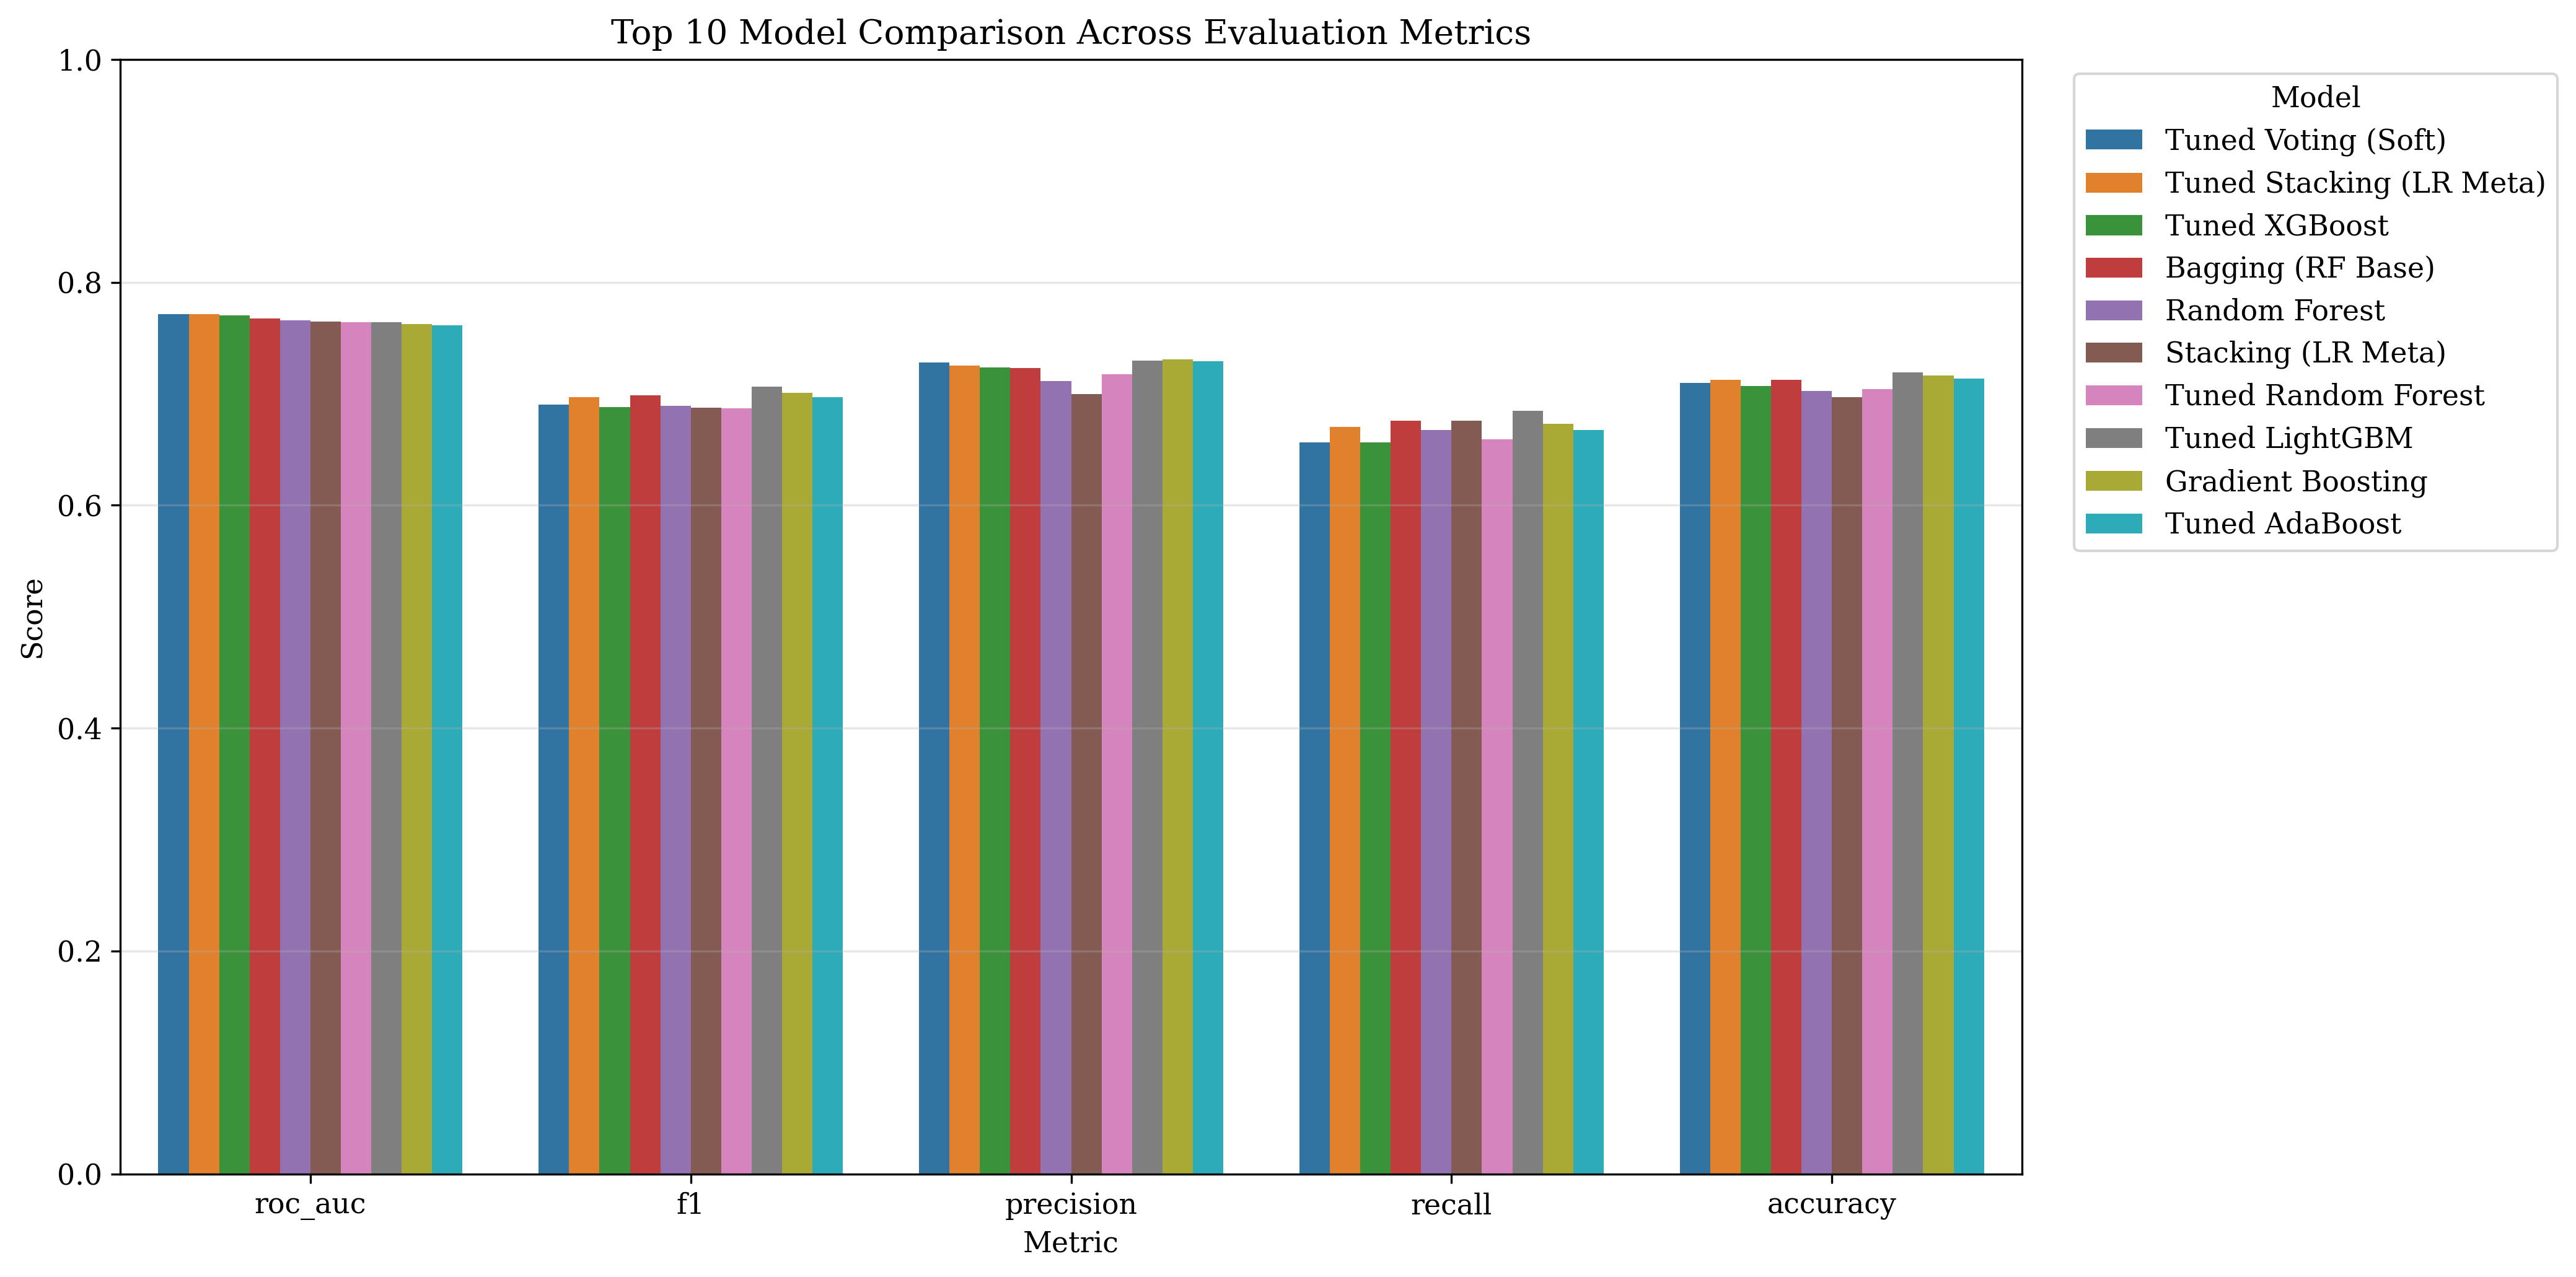

In [18]:
# ============================================================================
# MODEL COMPARISON CHART
# ============================================================================

print("\nPlotting Model Comparison Chart")
print("=" * 70)

top_models_plot = final_results_df.head(10).copy()

# If model_name already exists, keep it.
# Otherwise create it from the index.
if "model_name" not in top_models_plot.columns:
    top_models_plot = top_models_plot.reset_index().rename(columns={"index": "model_name"})
else:
    top_models_plot = top_models_plot.reset_index(drop=True)

plot_metrics = ["roc_auc", "f1", "precision", "recall", "accuracy"]

# Keep only needed columns and force metrics to numeric
top_models_plot = top_models_plot[["model_name"] + plot_metrics].copy()
for col in plot_metrics:
    top_models_plot[col] = pd.to_numeric(top_models_plot[col], errors="coerce")

plot_df = pd.melt(
    top_models_plot,
    id_vars="model_name",
    value_vars=plot_metrics,
    var_name="metric",
    value_name="score"
)

plt.figure(figsize=(14, 7))
sns.barplot(data=plot_df, x="metric", y="score", hue="model_name")
plt.ylim(0, 1)
plt.xlabel("Metric")
plt.ylabel("Score")
plt.title("Top 10 Model Comparison Across Evaluation Metrics")
plt.legend(title="Model", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.savefig(dissertation_dir / "figures" / "top10_model_comparison_chart.png", bbox_inches="tight")
plt.show()


Plotting Top 5 ROC-AUC Ranking


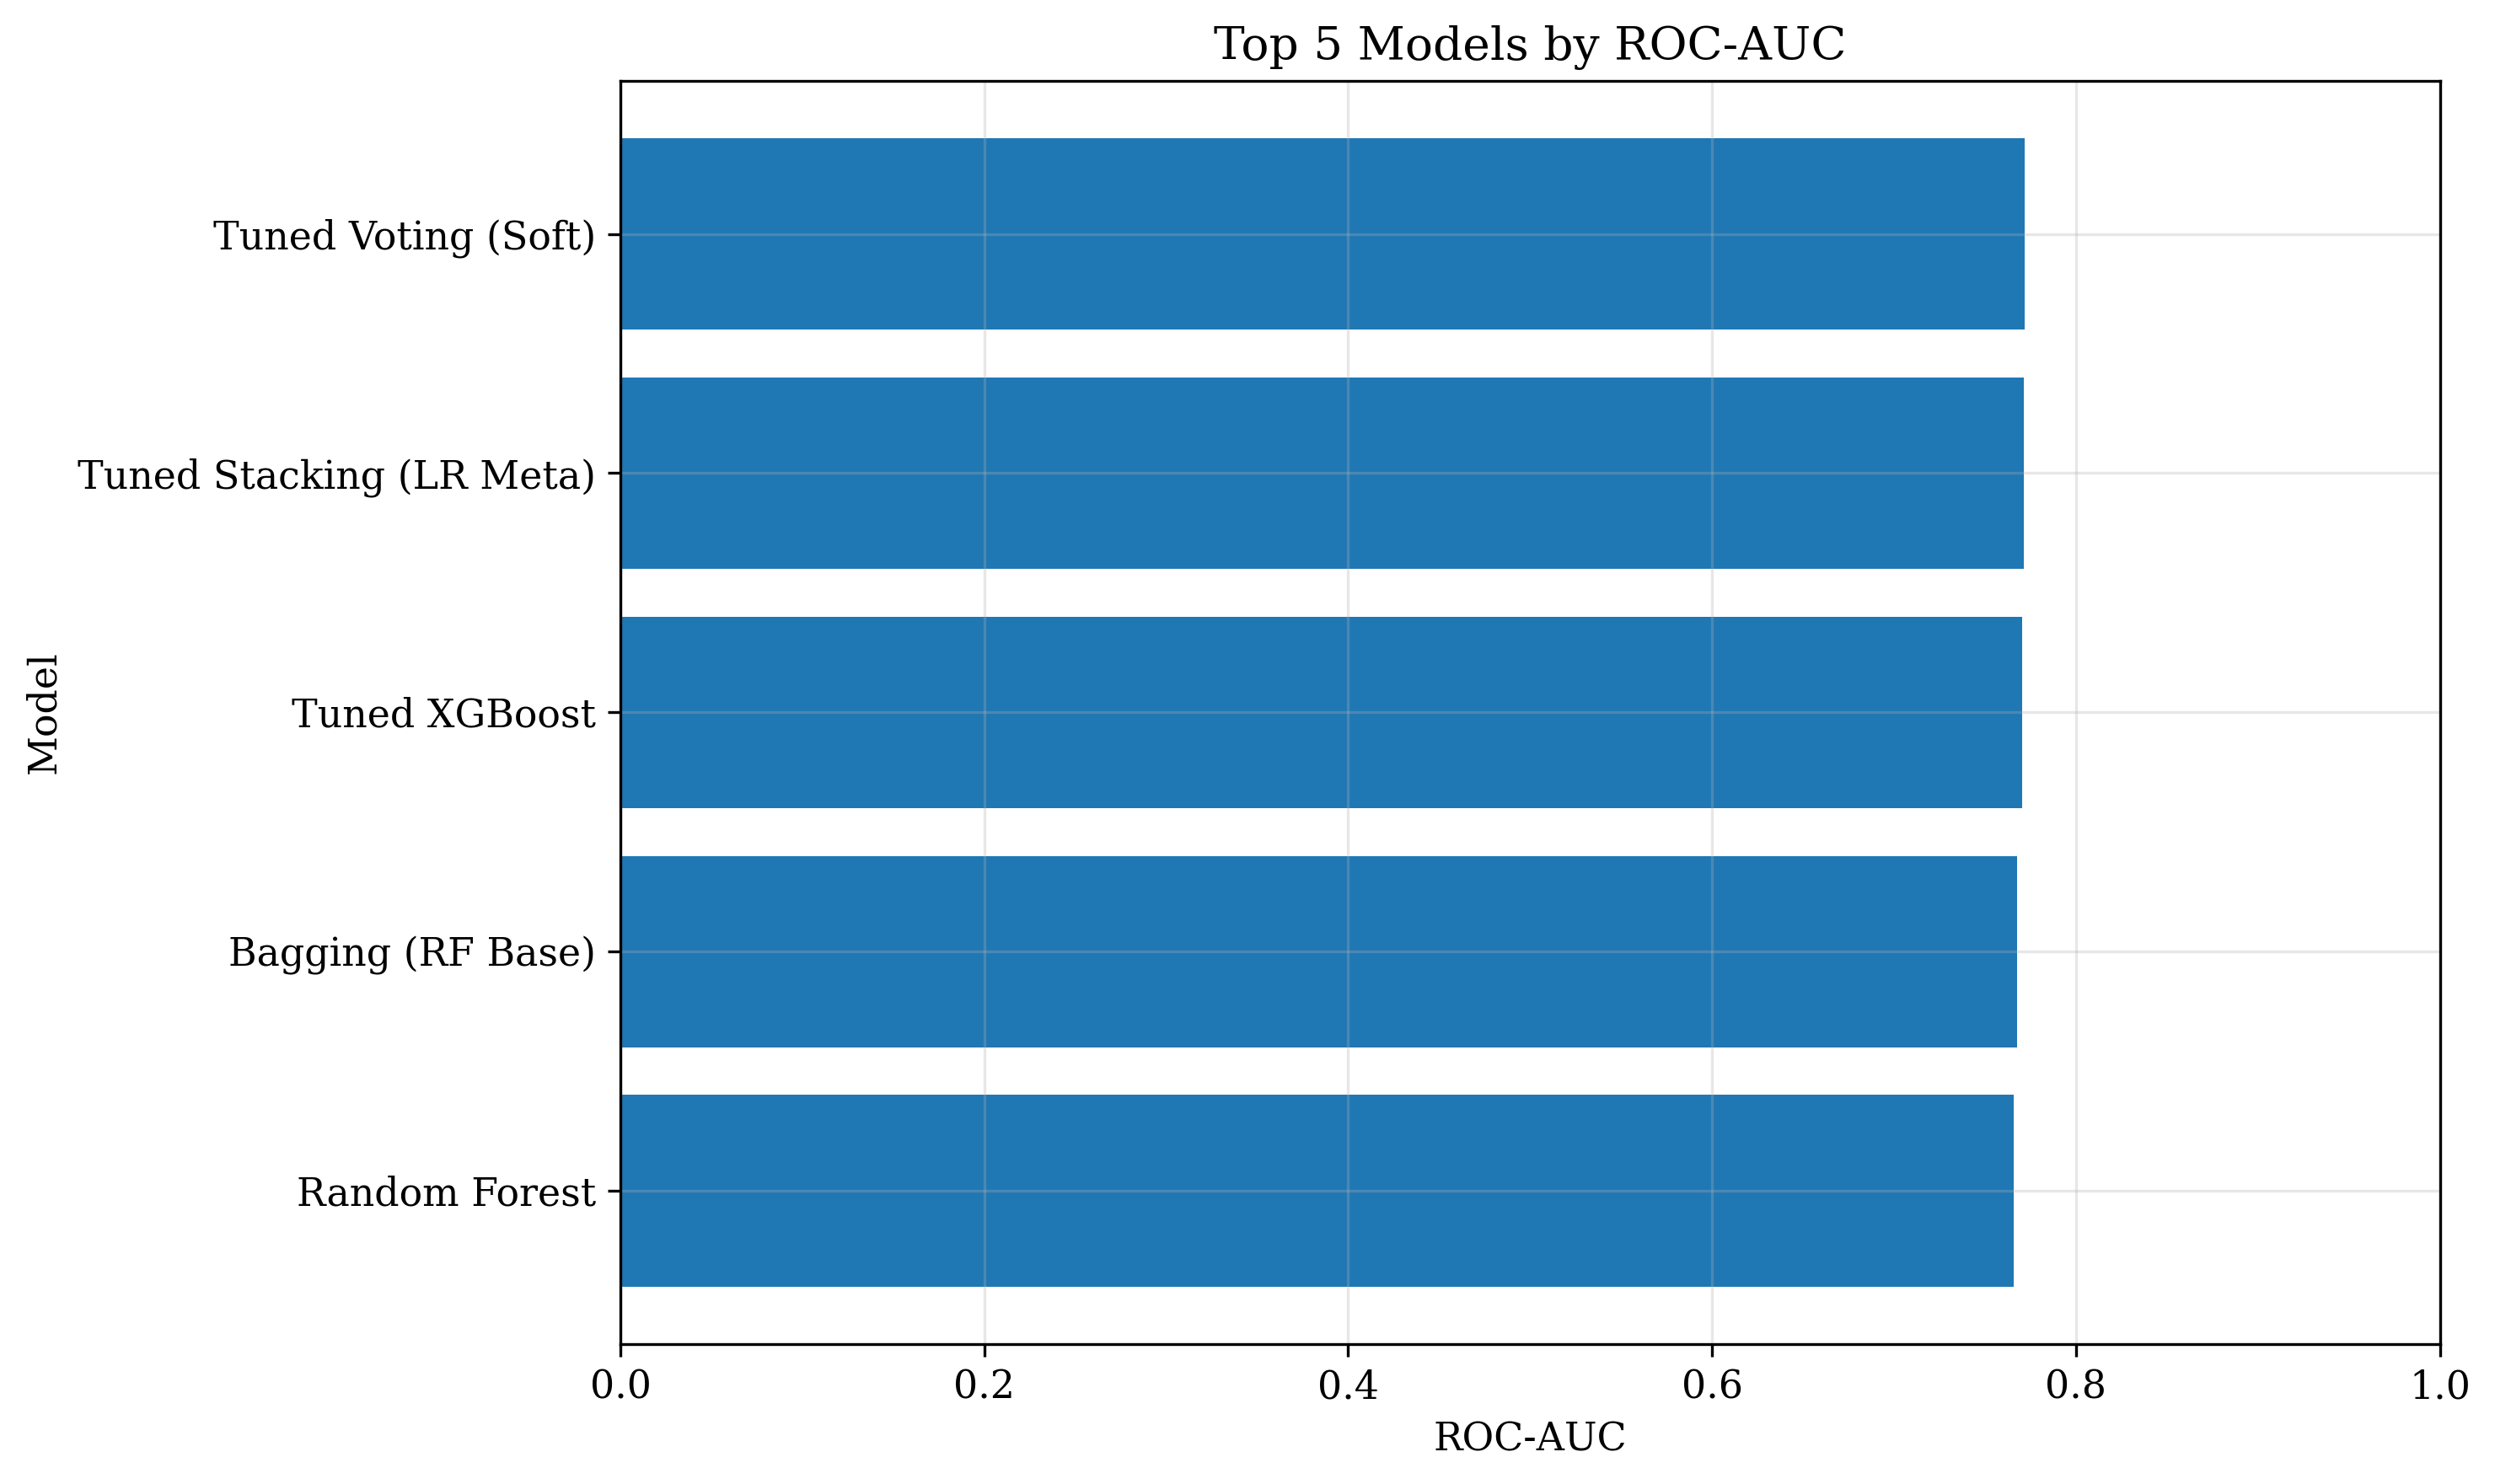

In [19]:
# ============================================================================
# TOP 5 ROC-AUC RANKING CHART
# ============================================================================

print("\nPlotting Top 5 ROC-AUC Ranking")
print("=" * 70)

top5_rank = final_results_df.head(5).copy()

if "model_name" not in top5_rank.columns:
    top5_rank = top5_rank.reset_index().rename(columns={"index": "model_name"})
else:
    top5_rank = top5_rank.reset_index(drop=True)

top5_rank["roc_auc"] = pd.to_numeric(top5_rank["roc_auc"], errors="coerce")
top5_rank = top5_rank[["model_name", "roc_auc"]].sort_values("roc_auc", ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(top5_rank["model_name"], top5_rank["roc_auc"])
plt.xlabel("ROC-AUC")
plt.ylabel("Model")
plt.title("Top 5 Models by ROC-AUC")
plt.xlim(0, 1)
plt.tight_layout()
plt.savefig(dissertation_dir / "figures" / "top5_roc_auc_ranking.png", bbox_inches="tight")
plt.show()

In [20]:

# ============================================================================
# REFIT BEST 5 MODELS FOR PLOTTING
# ============================================================================

print("\nRefitting Best 5 Models")
print("=" * 70)

all_models_dict = {}
all_models_dict.update(INDIVIDUAL_MODELS)
all_models_dict.update(ENSEMBLE_MODELS)
all_models_dict.update(tuned_models)
all_models_dict.update(TUNED_ENSEMBLES)

fitted_top5_models = {}

for model_name in top5_names:
    print(f"Fitting {model_name}...")
    model = clone(all_models_dict[model_name])

    X_train_use, X_test_use = get_train_test_for_model(model_name)

    model.fit(X_train_use, y_train)

    fitted_top5_models[model_name] = {
        "model": model,
        "X_test": X_test_use
    }

print("Top 5 refitted successfully")


Refitting Best 5 Models
Fitting Tuned Voting (Soft)...
Fitting Tuned Stacking (LR Meta)...
Fitting Tuned XGBoost...
Fitting Bagging (RF Base)...
Fitting Random Forest...
Top 5 refitted successfully



Plotting Confusion Matrices


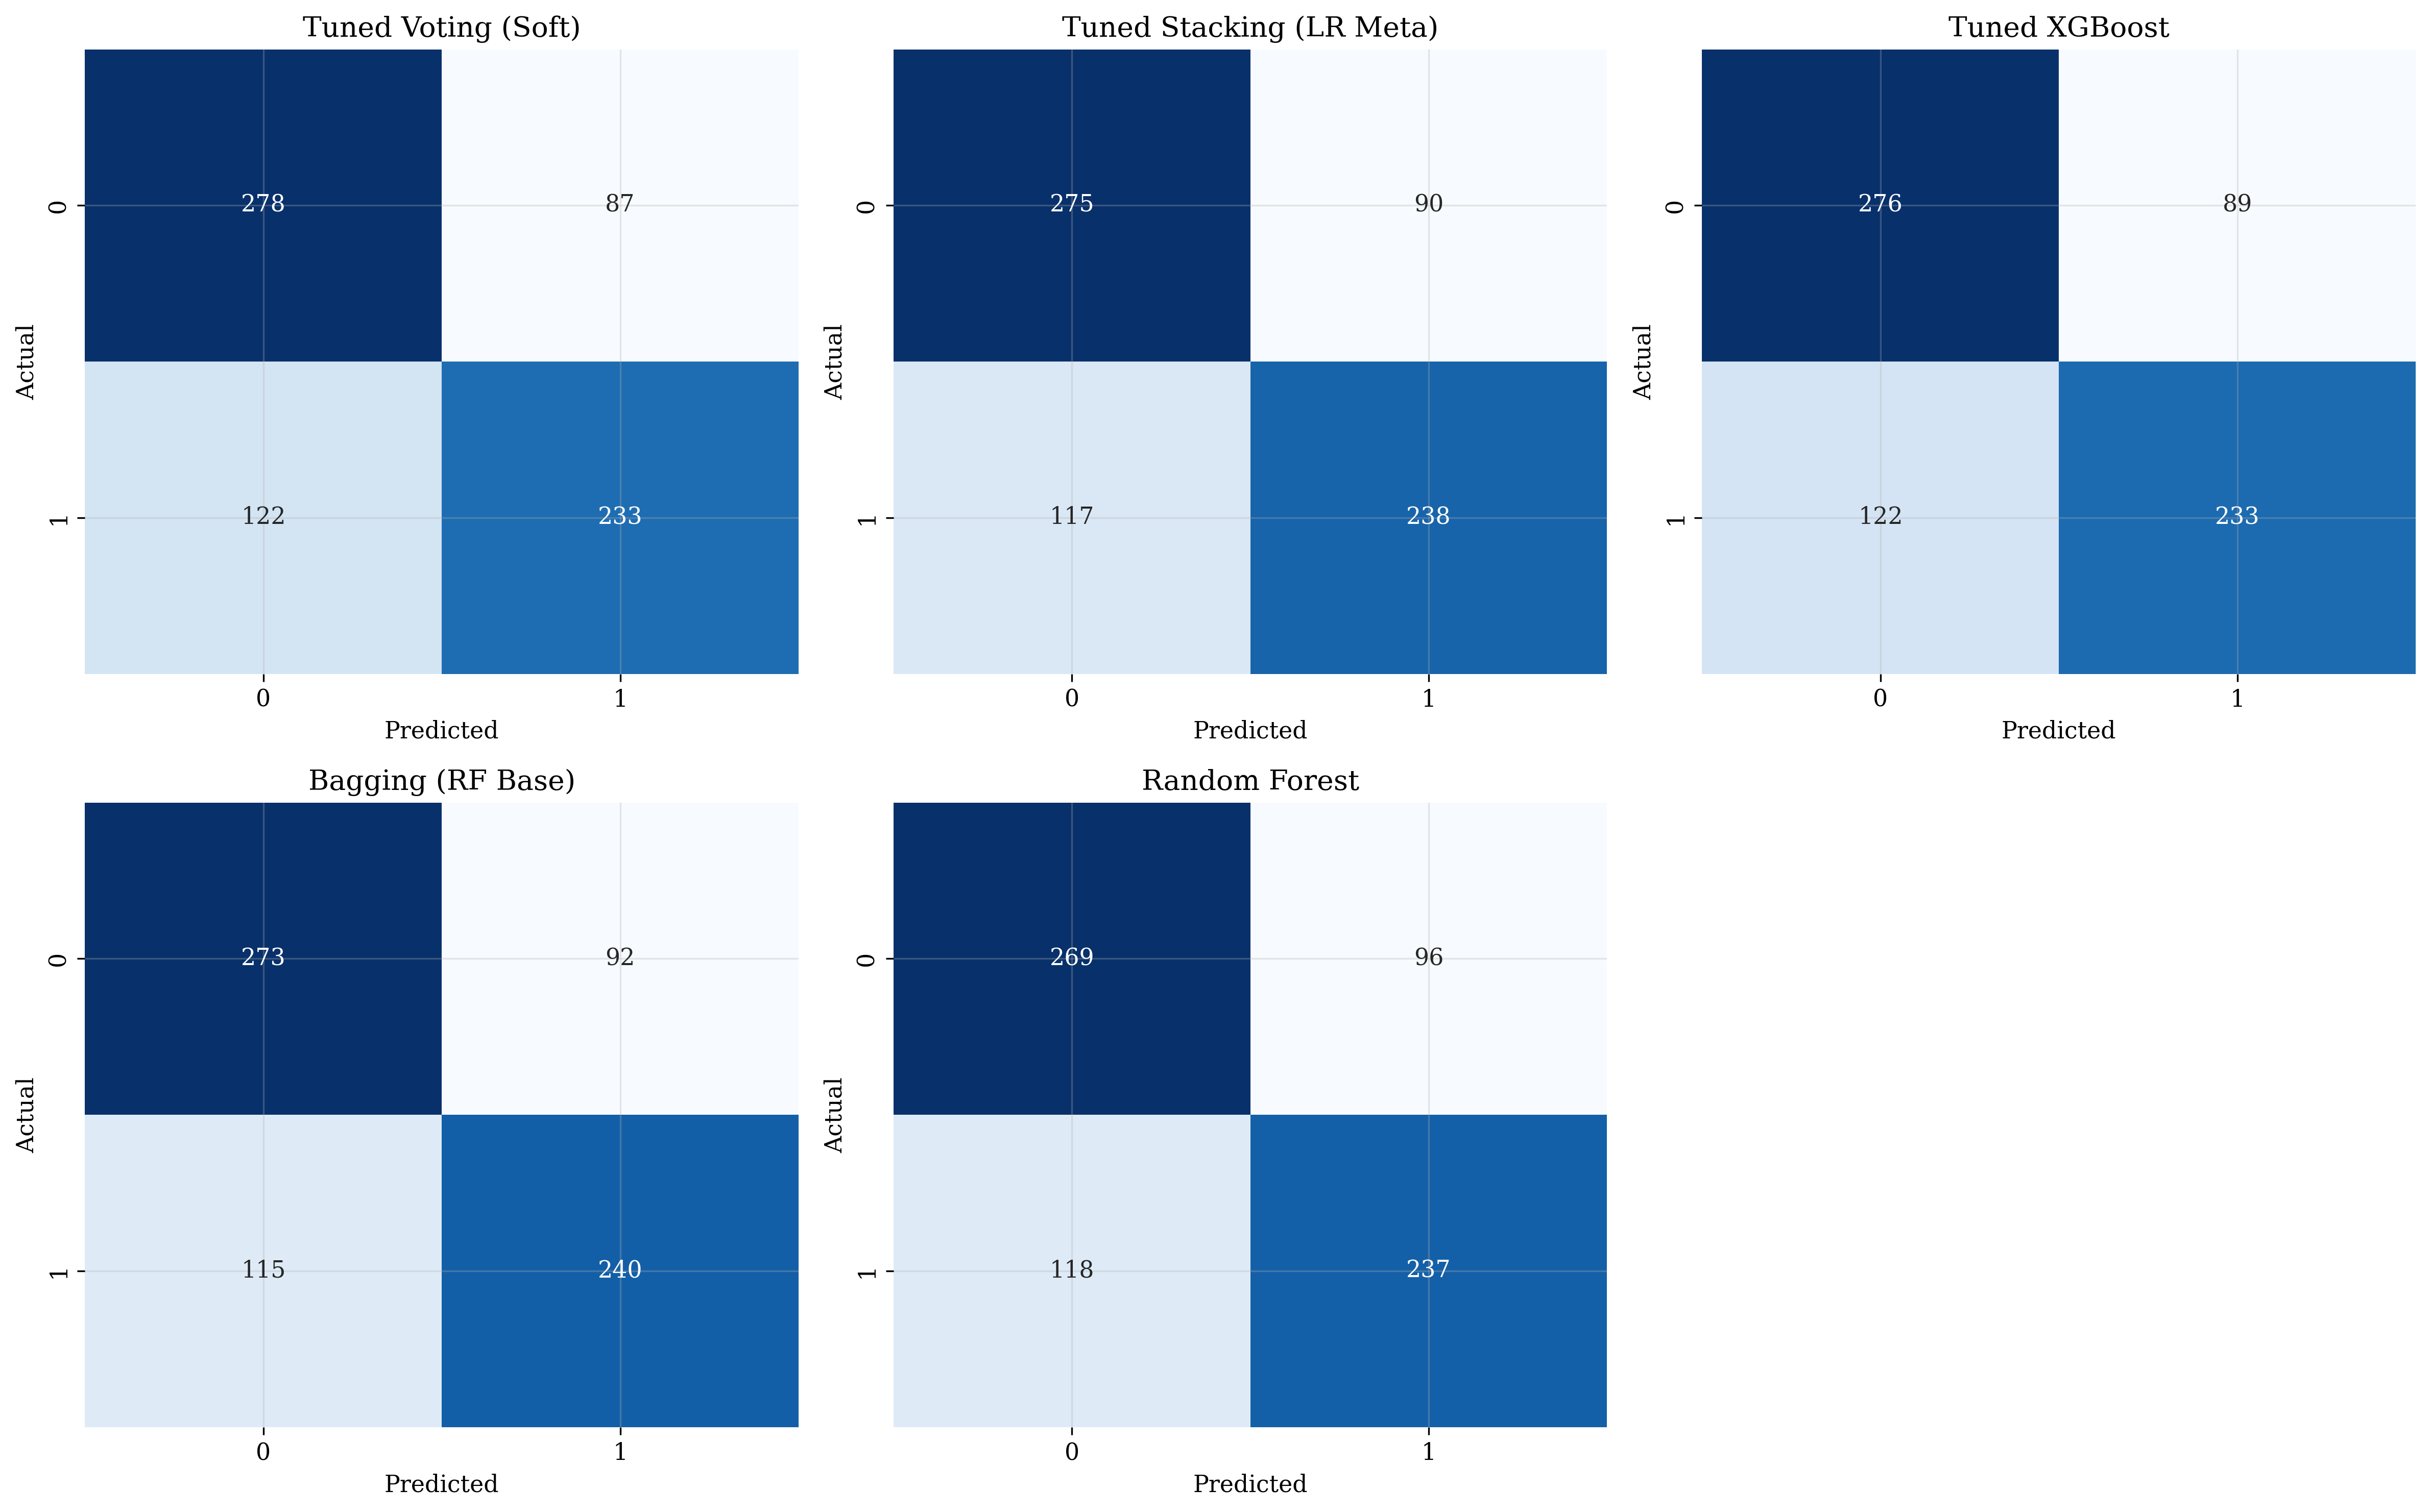

In [21]:
# ============================================================================
# CONFUSION MATRICES FOR BEST 5 MODELS
# ============================================================================

print("\nPlotting Confusion Matrices")
print("=" * 70)

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, model_name in enumerate(top5_names):
    ax = axes[i]
    model = fitted_top5_models[model_name]["model"]
    X_test_use = fitted_top5_models[model_name]["X_test"]

    y_pred = model.predict(X_test_use)
    cm = confusion_matrix(y_test, y_pred)

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=False,
        ax=ax
    )
    ax.set_title(model_name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

for j in range(len(top5_names), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.savefig(dissertation_dir / "figures" / "top5_confusion_matrices.png", bbox_inches="tight")
plt.show()


Plotting ROC Curves


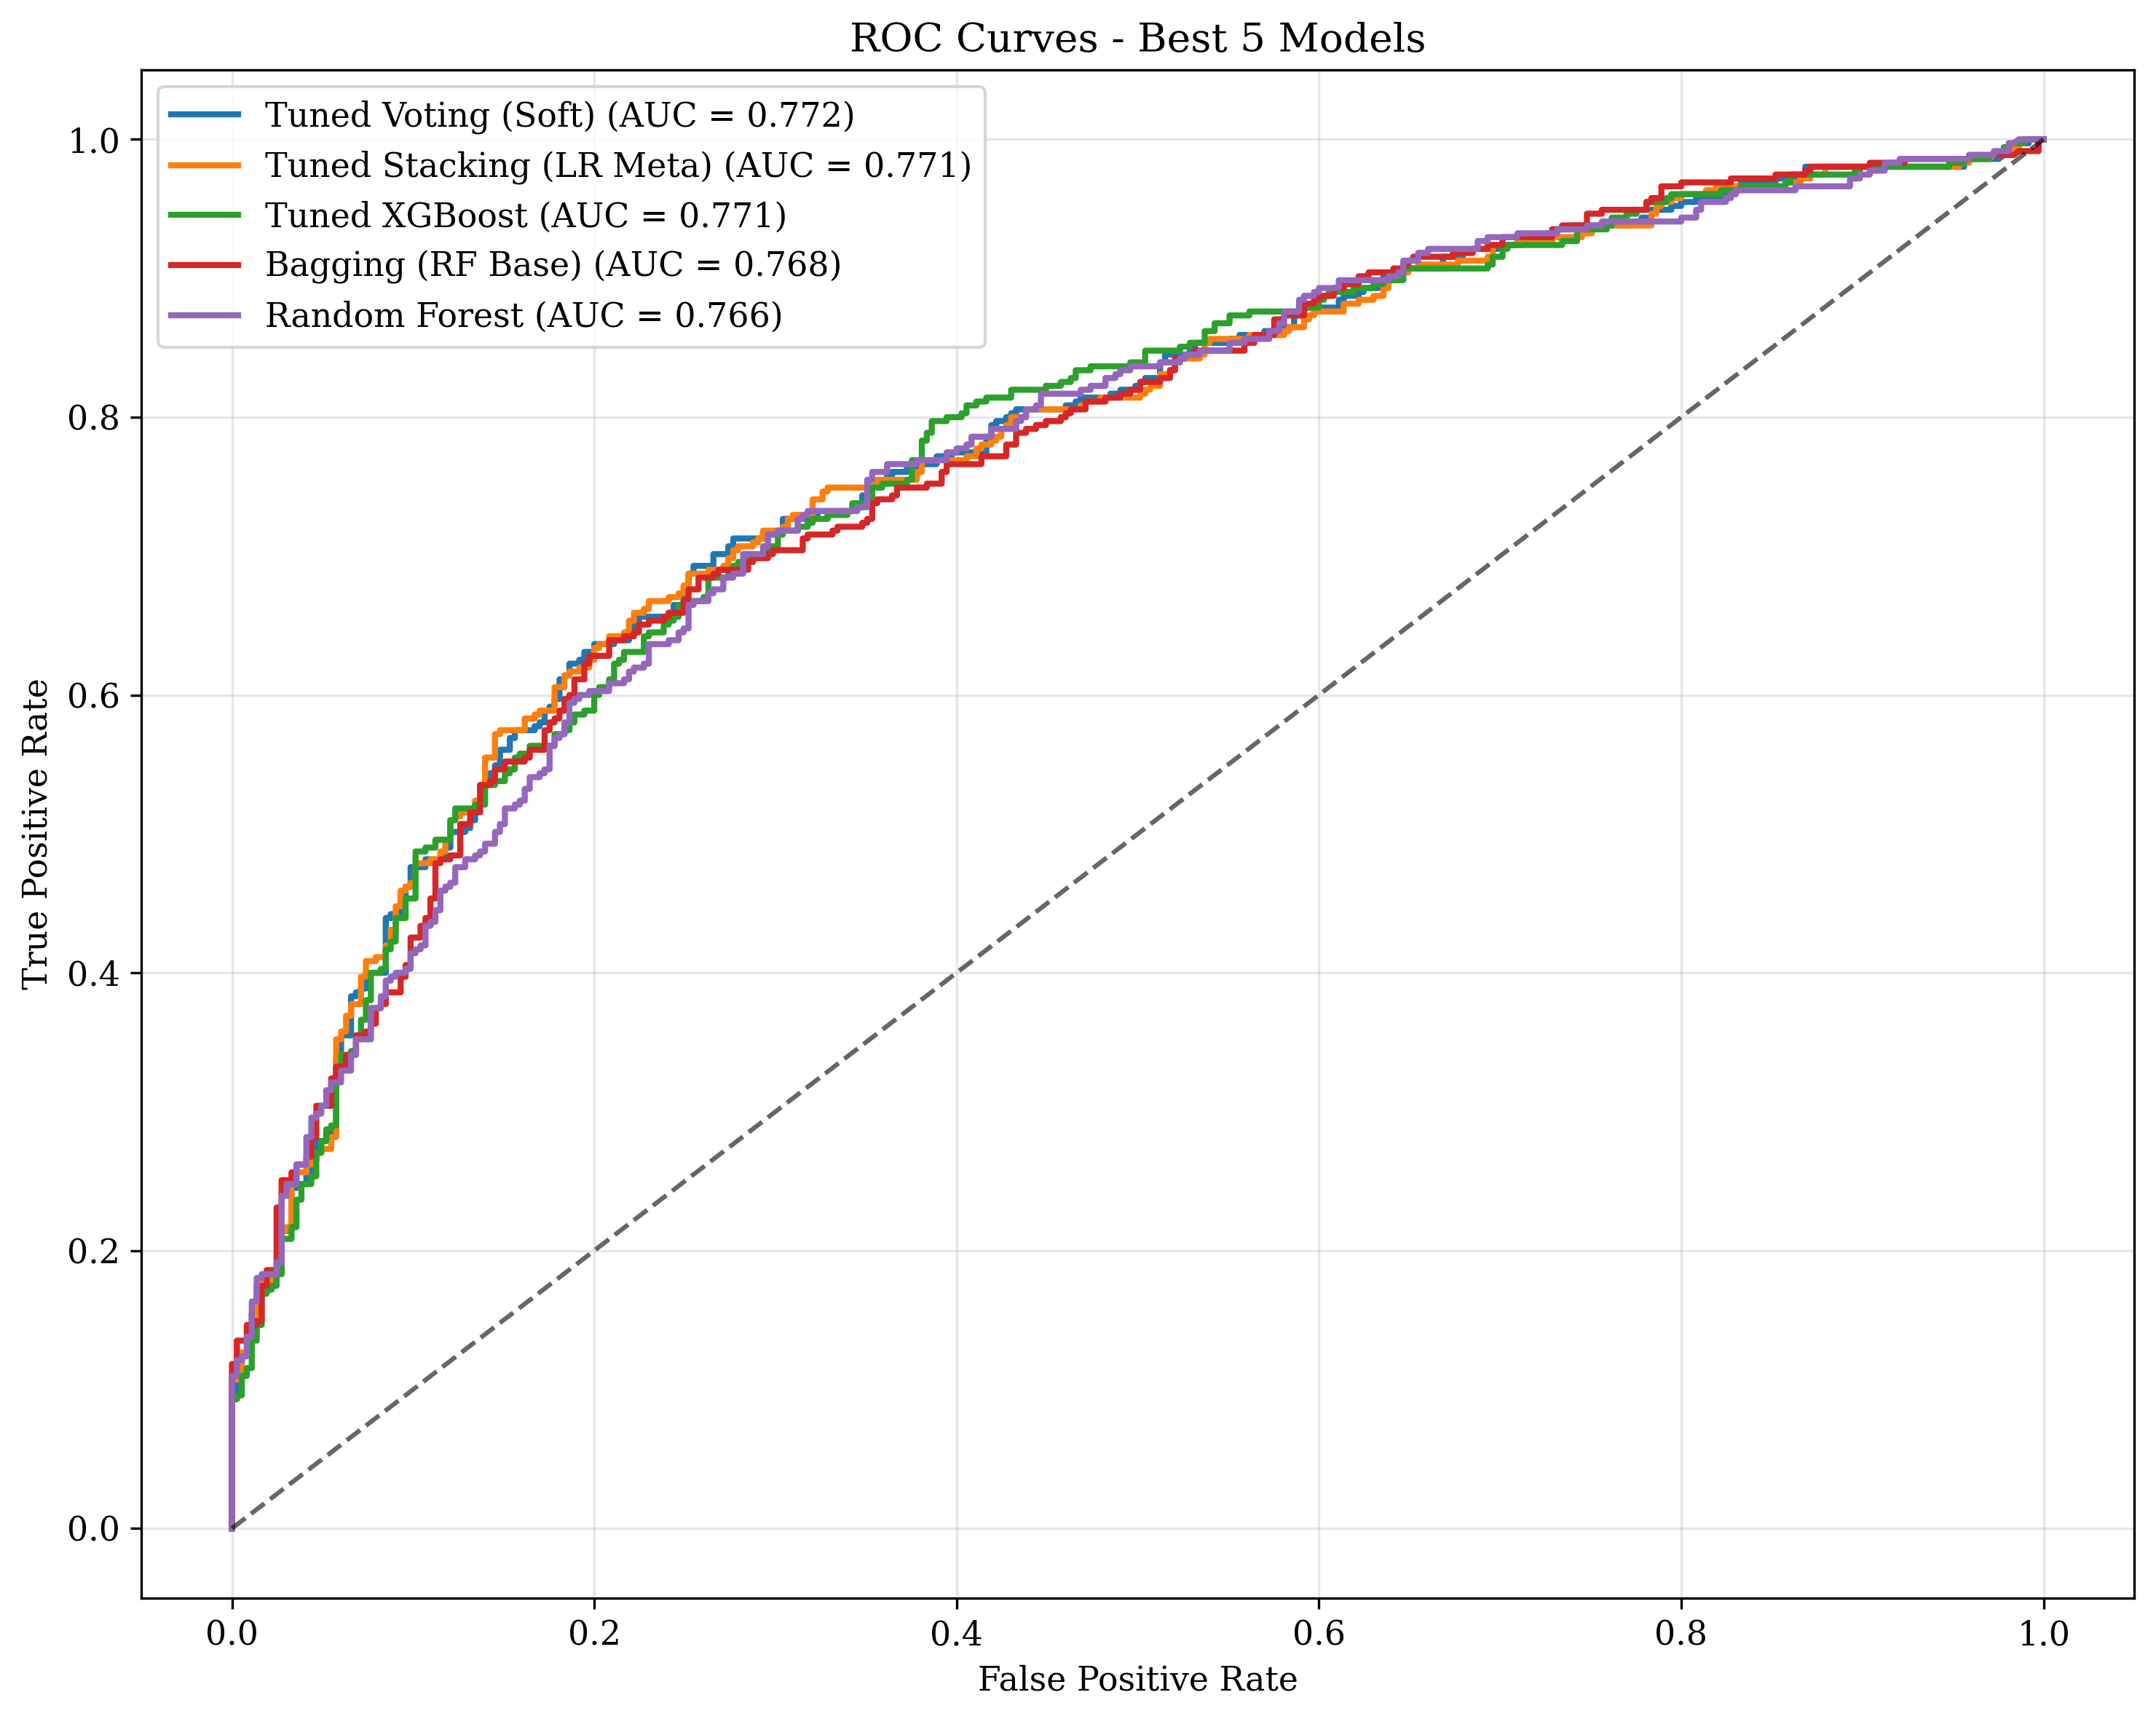

In [22]:
# ============================================================================
# ROC CURVES FOR BEST 5 MODELS
# ============================================================================

print("\nPlotting ROC Curves")
print("=" * 70)

plt.figure(figsize=(10, 8))

for model_name in top5_names:
    model = fitted_top5_models[model_name]["model"]
    X_test_use = fitted_top5_models[model_name]["X_test"]

    y_score = normalize_scores_for_plot(get_model_scores(model, X_test_use))
    if y_score is None:
        continue

    fpr, tpr, _ = roc_curve(y_test, y_score)
    auc = roc_auc_score(y_test, y_score)

    plt.plot(fpr, tpr, linewidth=2, label=f"{model_name} (AUC = {auc:.3f})")

plt.plot([0, 1], [0, 1], "k--", alpha=0.6)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves - Best 5 Models")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(dissertation_dir / "figures" / "top5_roc_curves.png", bbox_inches="tight")
plt.show()


Plotting Precision-Recall Curves


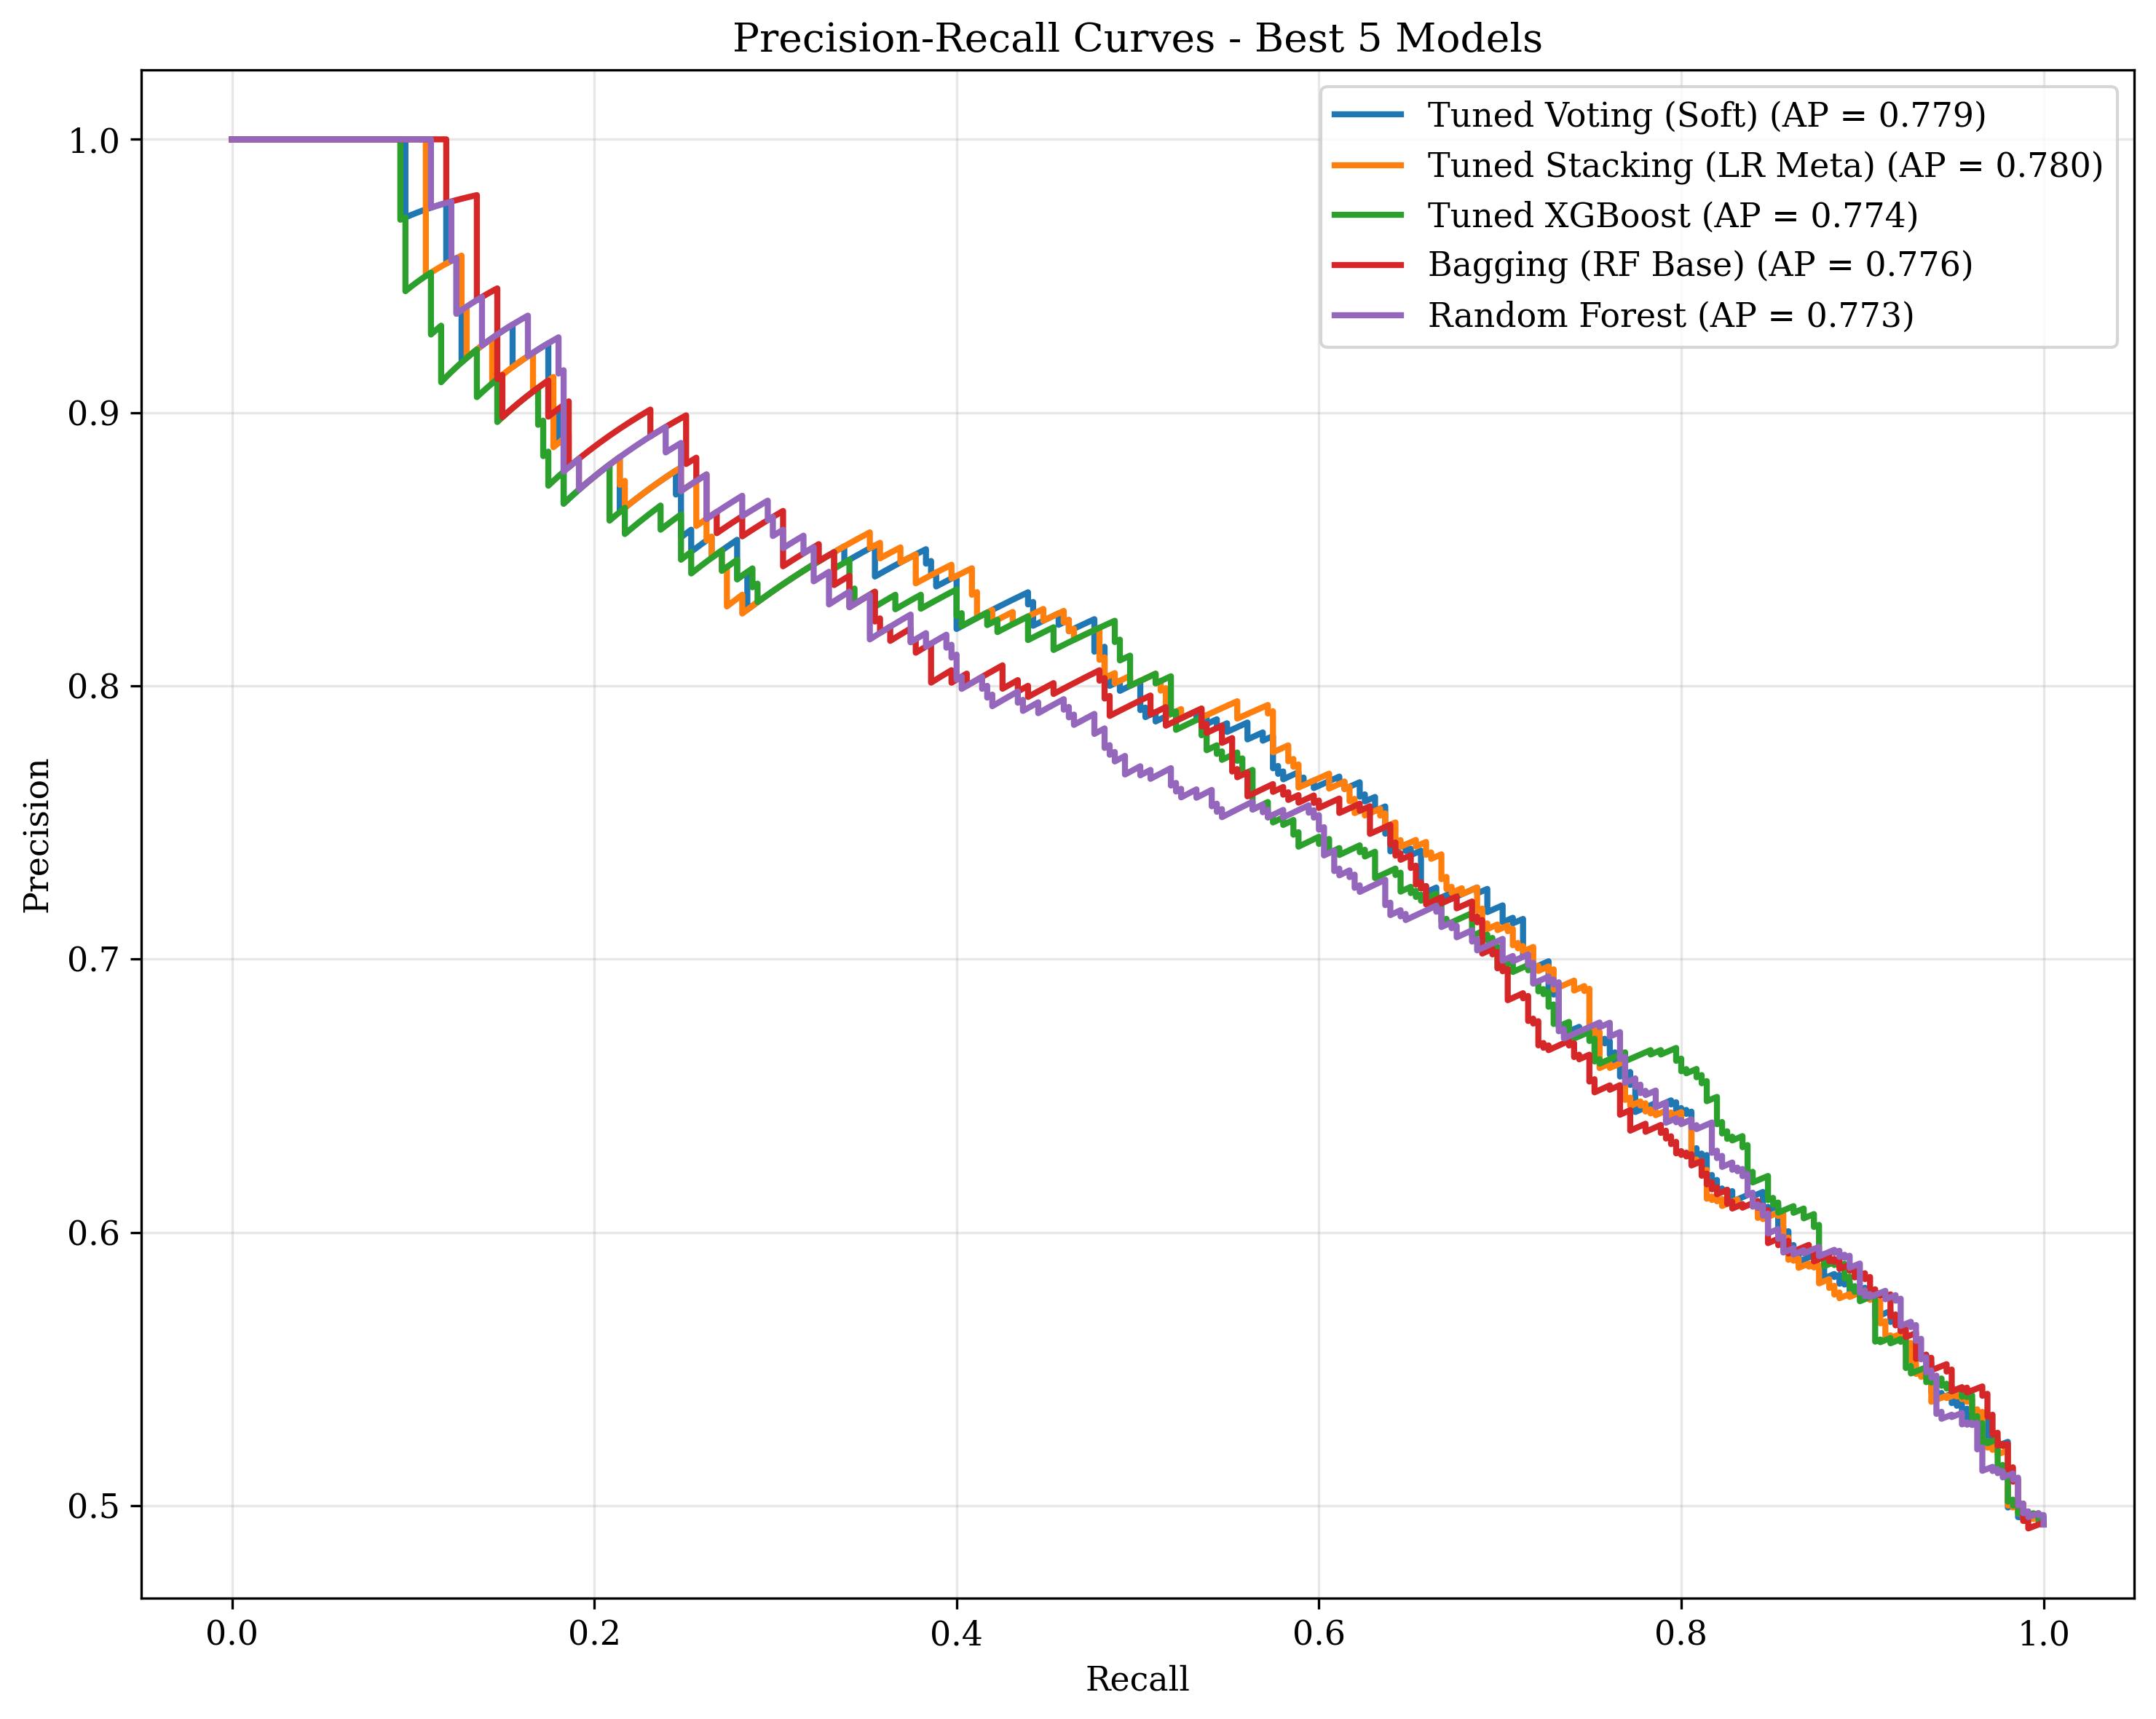

In [23]:
# ============================================================================
# PRECISION-RECALL CURVES FOR BEST 5 MODELS
# ============================================================================

print("\nPlotting Precision-Recall Curves")
print("=" * 70)

plt.figure(figsize=(10, 8))

for model_name in top5_names:
    model = fitted_top5_models[model_name]["model"]
    X_test_use = fitted_top5_models[model_name]["X_test"]

    y_score = normalize_scores_for_plot(get_model_scores(model, X_test_use))
    if y_score is None:
        continue

    precision_vals, recall_vals, _ = precision_recall_curve(y_test, y_score)
    ap = average_precision_score(y_test, y_score)

    plt.plot(recall_vals, precision_vals, linewidth=2, label=f"{model_name} (AP = {ap:.3f})")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curves - Best 5 Models")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(dissertation_dir / "figures" / "top5_pr_curves.png", bbox_inches="tight")
plt.show()


Plotting Metric Comparison for Best 5 Models


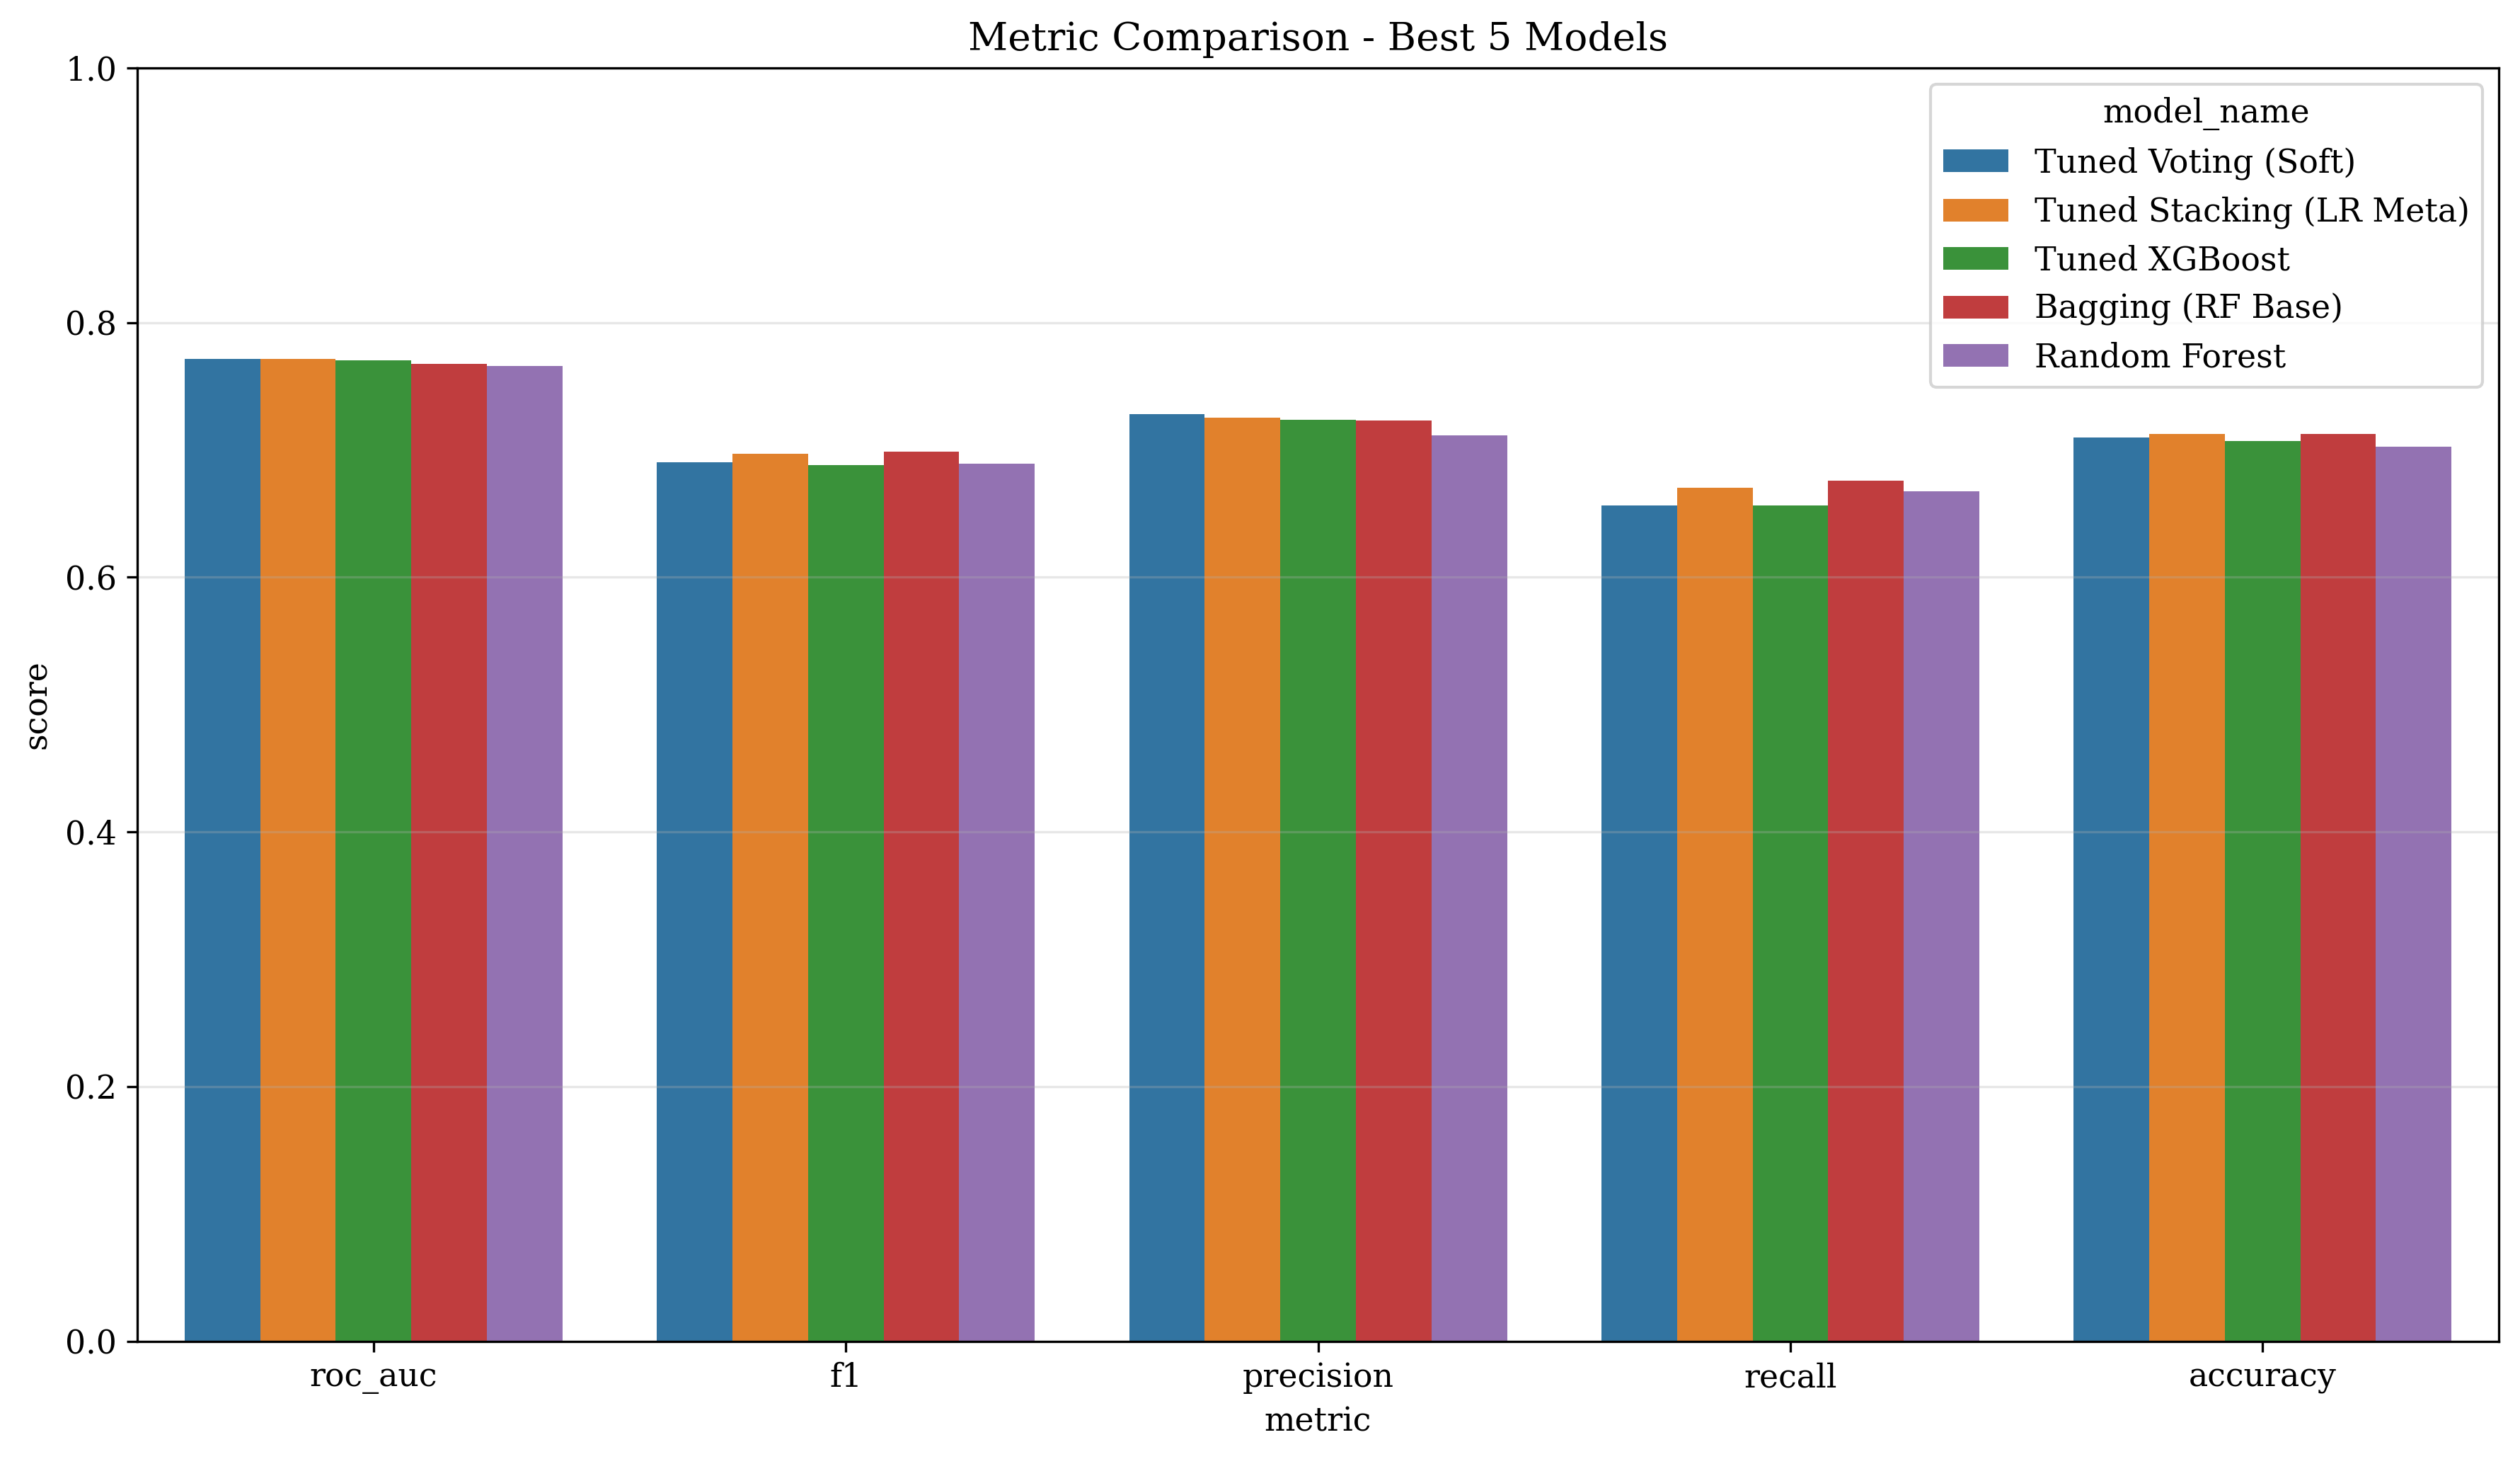

In [24]:
# ============================================================================
# METRIC BAR CHART FOR BEST 5 MODELS
# ============================================================================

print("\nPlotting Metric Comparison for Best 5 Models")
print("=" * 70)

top5_df = final_results_df.loc[top5_names, ["roc_auc", "f1", "precision", "recall", "accuracy"]].copy()
top5_df = top5_df.reset_index().rename(columns={"index": "model_name"})

plot_df = top5_df.melt(id_vars="model_name", var_name="metric", value_name="score")

plt.figure(figsize=(12, 7))
sns.barplot(data=plot_df, x="metric", y="score", hue="model_name")
plt.ylim(0, 1)
plt.title("Metric Comparison - Best 5 Models")
plt.tight_layout()
plt.savefig(dissertation_dir / "figures" / "top5_metric_comparison.png", bbox_inches="tight")
plt.show()


Threshold Tuning
Best model: Tuned Voting (Soft)
Best threshold by F1: 0.40
threshold    0.400000
accuracy     0.684722
precision    0.646119
recall       0.797183
f1           0.713745
Name: 6, dtype: float64
Saved: /Users/collinsbiwott/Desktop/ecd_final_ml/reports/tables/best_model_threshold_tuning.csv


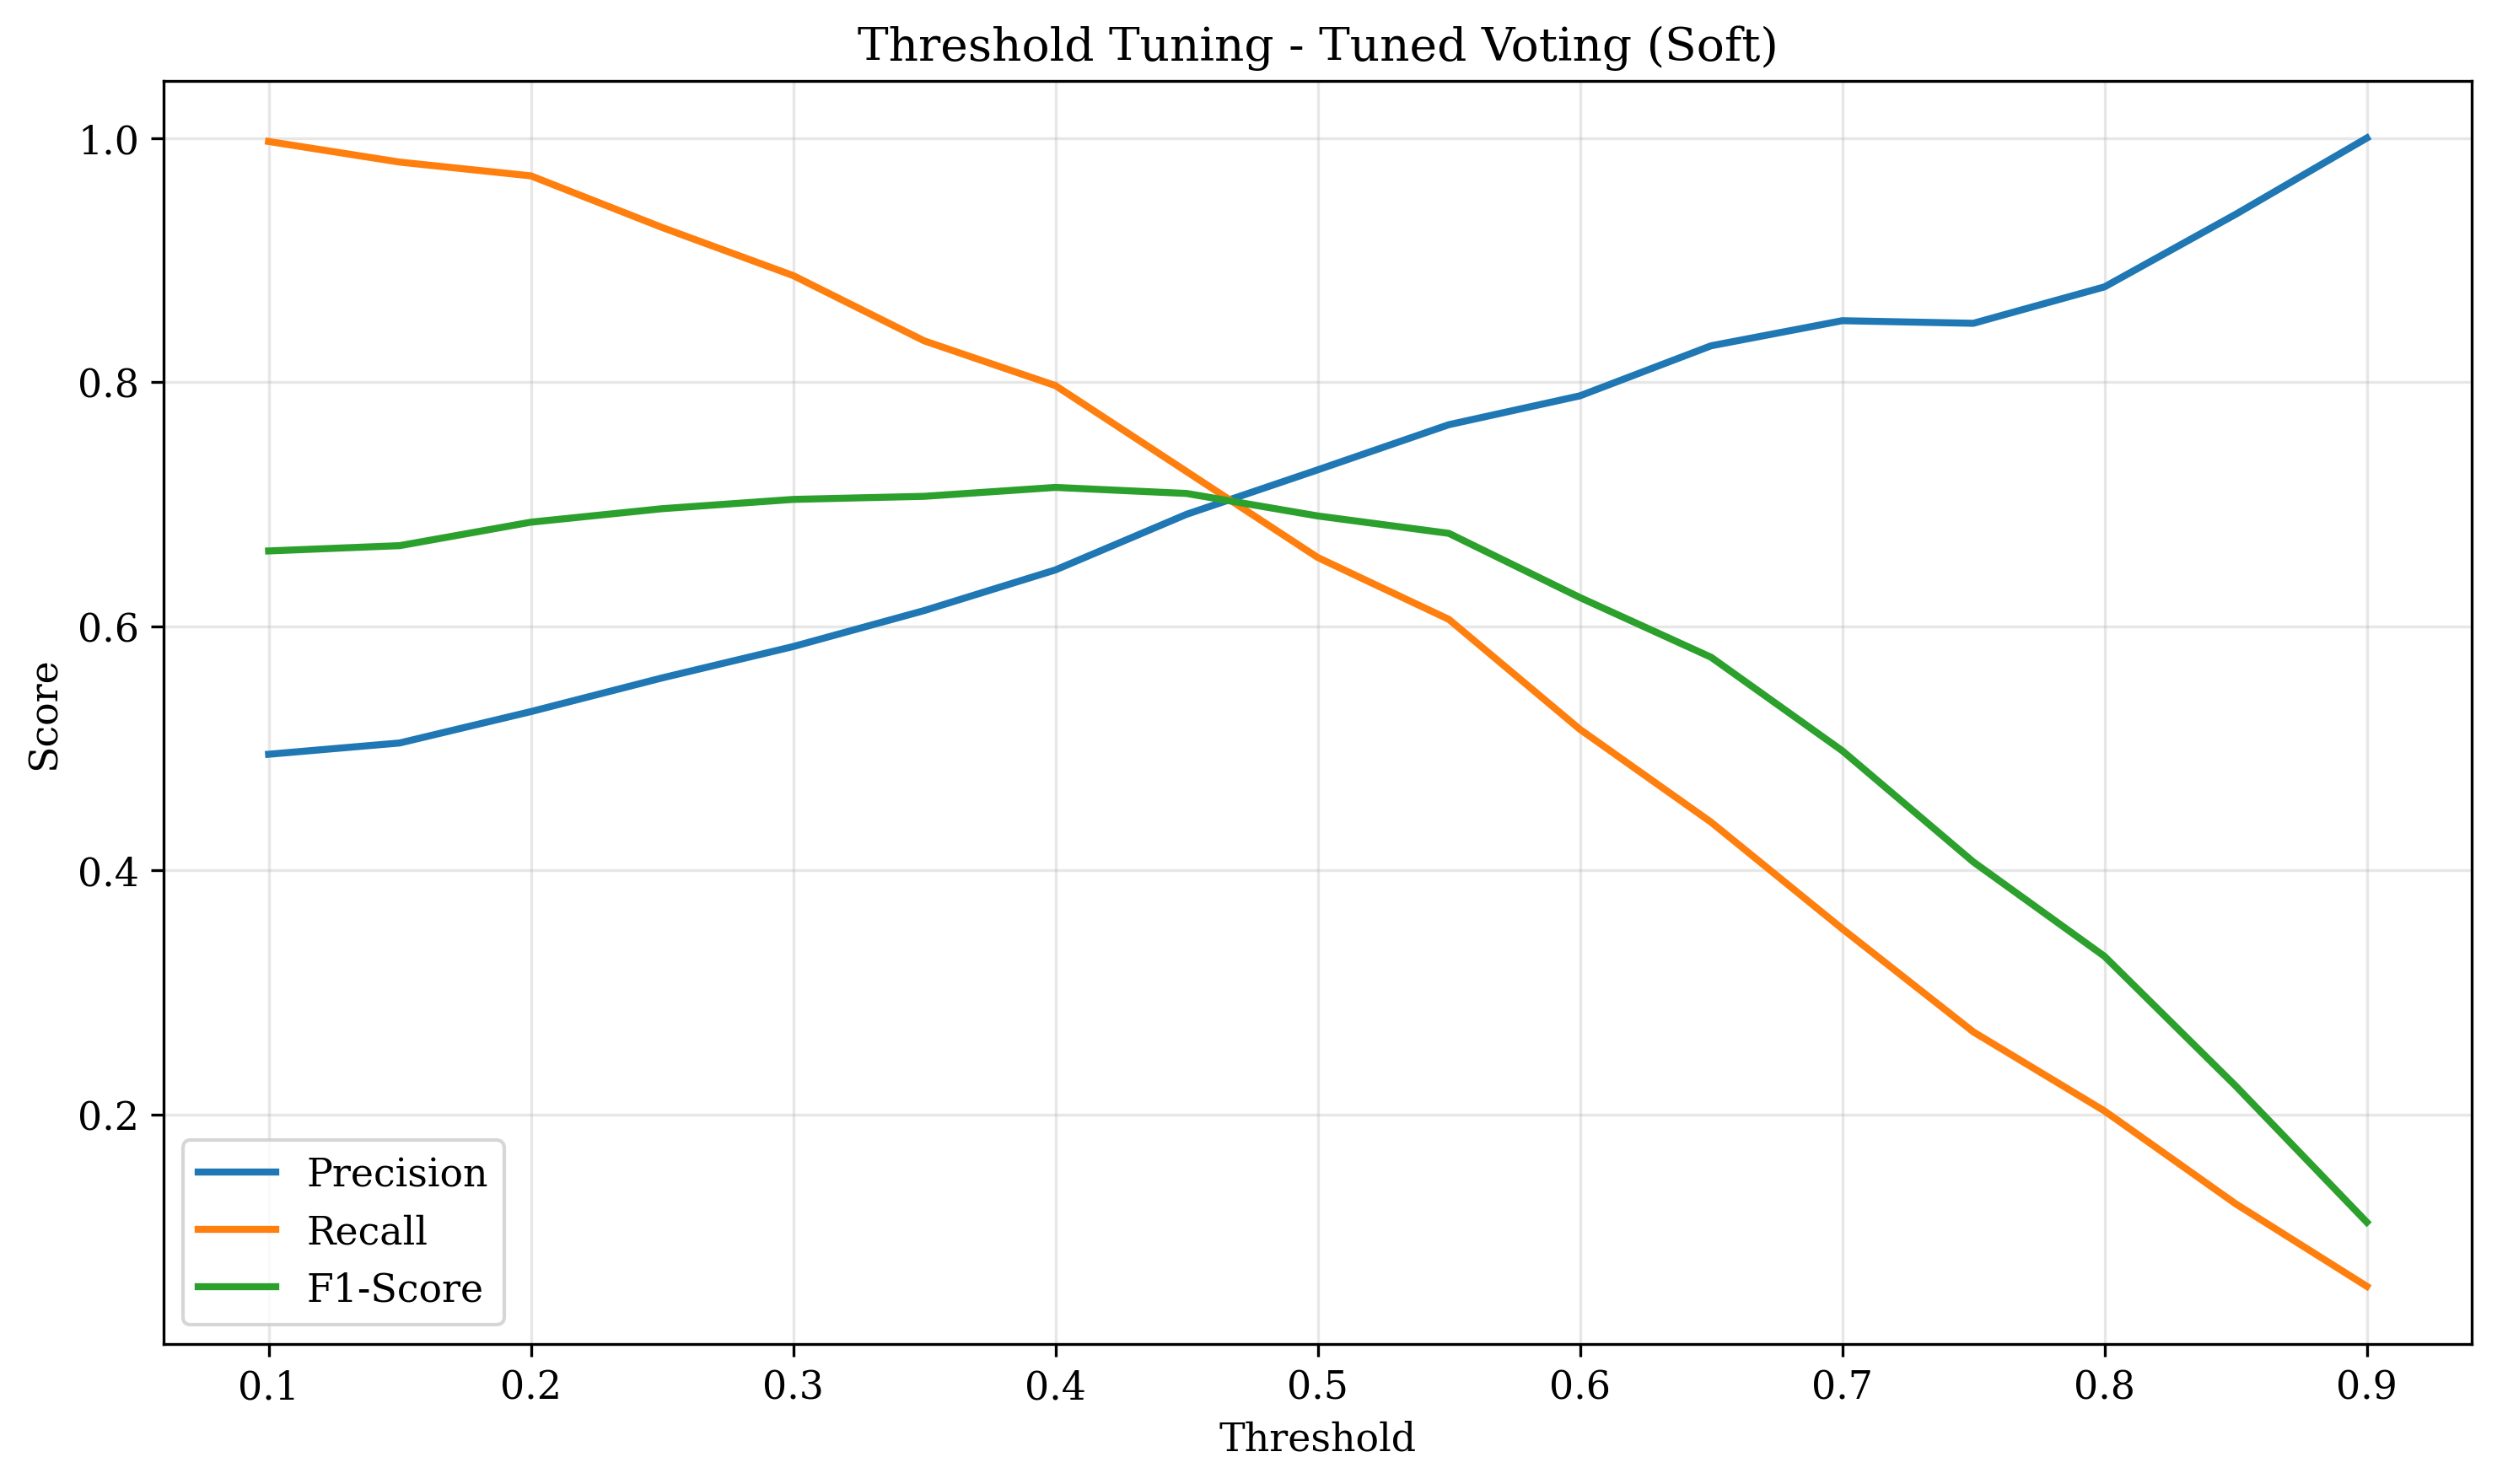

In [25]:

# ============================================================================
# THRESHOLD TUNING FOR BEST MODEL
# ============================================================================

print("\nThreshold Tuning")
print("=" * 70)

best_model_name = top5_names[0]
best_model = fitted_top5_models[best_model_name]["model"]
best_model_X_test = fitted_top5_models[best_model_name]["X_test"]

y_score_best = normalize_scores_for_plot(get_model_scores(best_model, best_model_X_test))

threshold_results = []

if y_score_best is not None:
    for threshold in np.arange(0.10, 0.91, 0.05):
        y_pred_thr = (y_score_best >= threshold).astype(int)

        threshold_results.append({
            "threshold": threshold,
            "accuracy": accuracy_score(y_test, y_pred_thr),
            "precision": precision_score(y_test, y_pred_thr, zero_division=0),
            "recall": recall_score(y_test, y_pred_thr, zero_division=0),
            "f1": f1_score(y_test, y_pred_thr, zero_division=0)
        })

    threshold_df = pd.DataFrame(threshold_results)
    best_threshold_row = threshold_df.sort_values("f1", ascending=False).iloc[0]

    print(f"Best model: {best_model_name}")
    print(f"Best threshold by F1: {best_threshold_row['threshold']:.2f}")
    print(best_threshold_row)

    save_dataframe(threshold_df, "best_model_threshold_tuning.csv")

    plt.figure(figsize=(10, 6))
    plt.plot(threshold_df["threshold"], threshold_df["precision"], label="Precision", linewidth=2)
    plt.plot(threshold_df["threshold"], threshold_df["recall"], label="Recall", linewidth=2)
    plt.plot(threshold_df["threshold"], threshold_df["f1"], label="F1-Score", linewidth=2)
    plt.xlabel("Threshold")
    plt.ylabel("Score")
    plt.title(f"Threshold Tuning - {best_model_name}")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(dissertation_dir / "figures" / "best_model_threshold_tuning.png", bbox_inches="tight")
    plt.show()
else:
    best_threshold_row = pd.Series({"threshold": 0.50})
    print("Threshold tuning skipped: model has no continuous scores")



Calibration Check
Brier Score: 0.1942


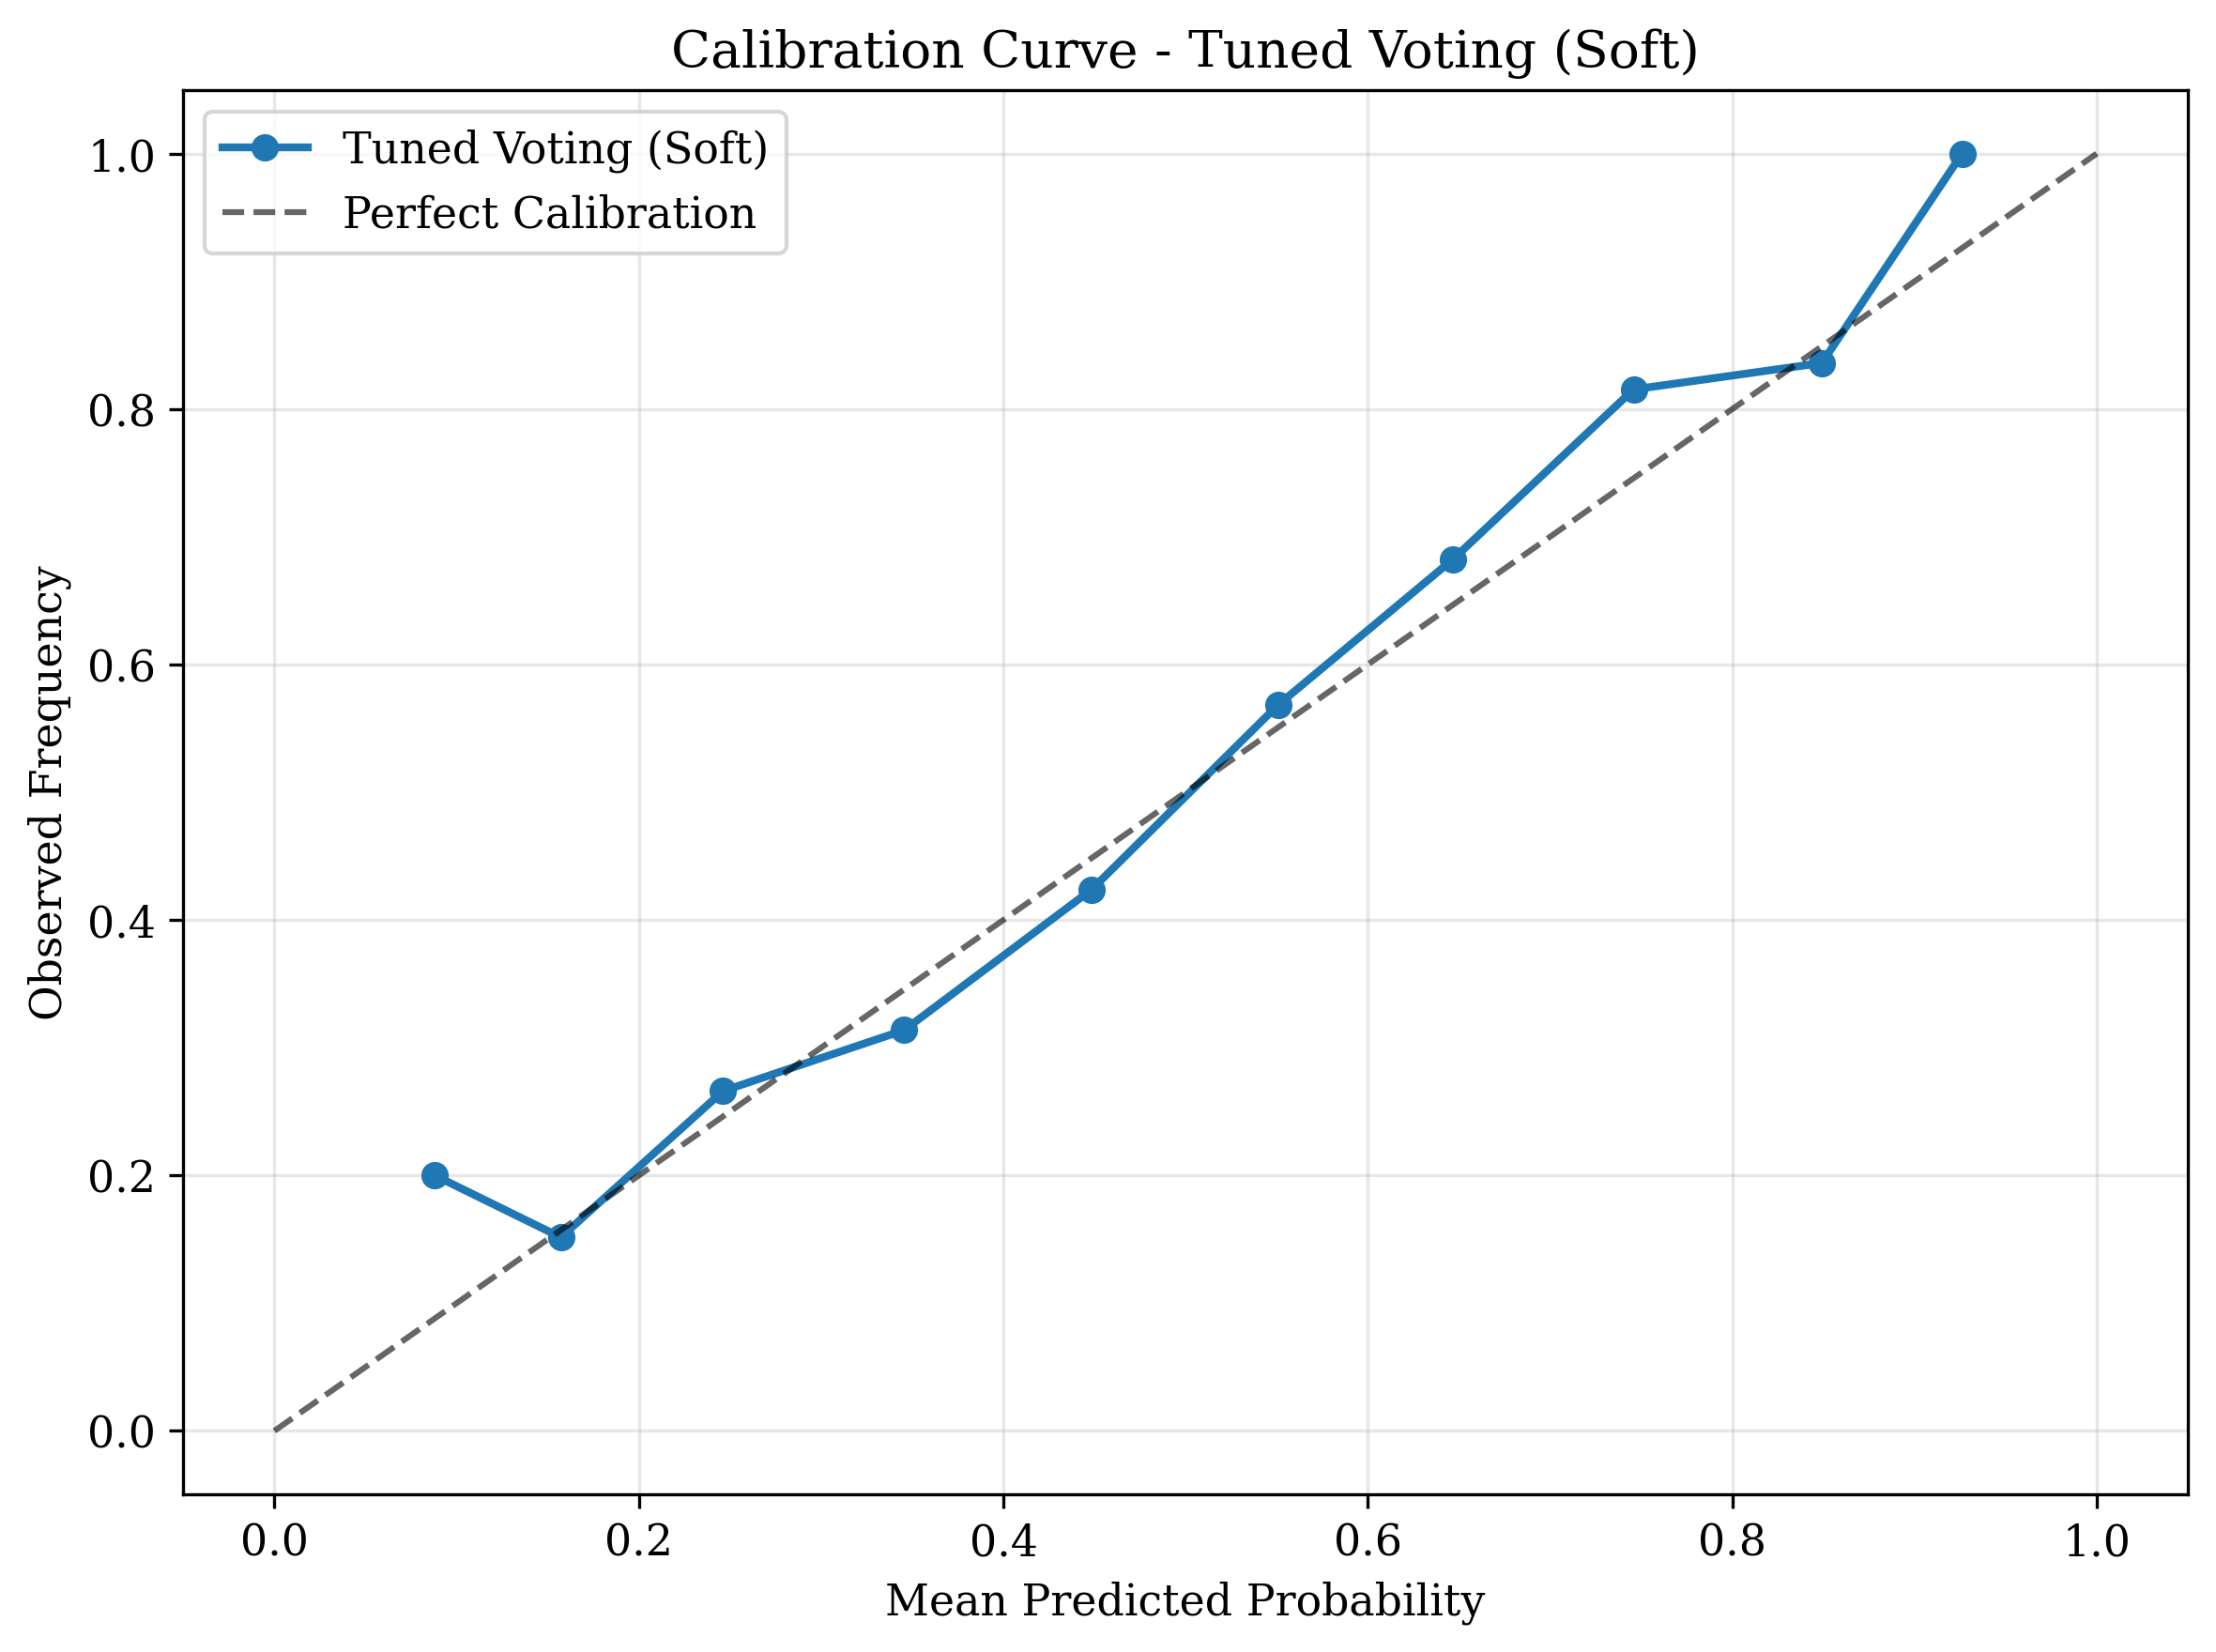

In [26]:
# ============================================================================
# CALIBRATION CURVE FOR BEST MODEL
# ============================================================================

print("\nCalibration Check")
print("=" * 70)

if y_score_best is not None:
    prob_true, prob_pred = calibration_curve(y_test, y_score_best, n_bins=10, strategy="uniform")
    brier = brier_score_loss(y_test, y_score_best)

    print(f"Brier Score: {brier:.4f}")

    plt.figure(figsize=(8, 6))
    plt.plot(prob_pred, prob_true, marker="o", linewidth=2, label=best_model_name)
    plt.plot([0, 1], [0, 1], "k--", alpha=0.6, label="Perfect Calibration")
    plt.xlabel("Mean Predicted Probability")
    plt.ylabel("Observed Frequency")
    plt.title(f"Calibration Curve - {best_model_name}")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(dissertation_dir / "figures" / "best_model_calibration_curve.png", bbox_inches="tight")
    plt.show()
else:
    print("Calibration skipped: model has no probability-like output")



Learning Curve


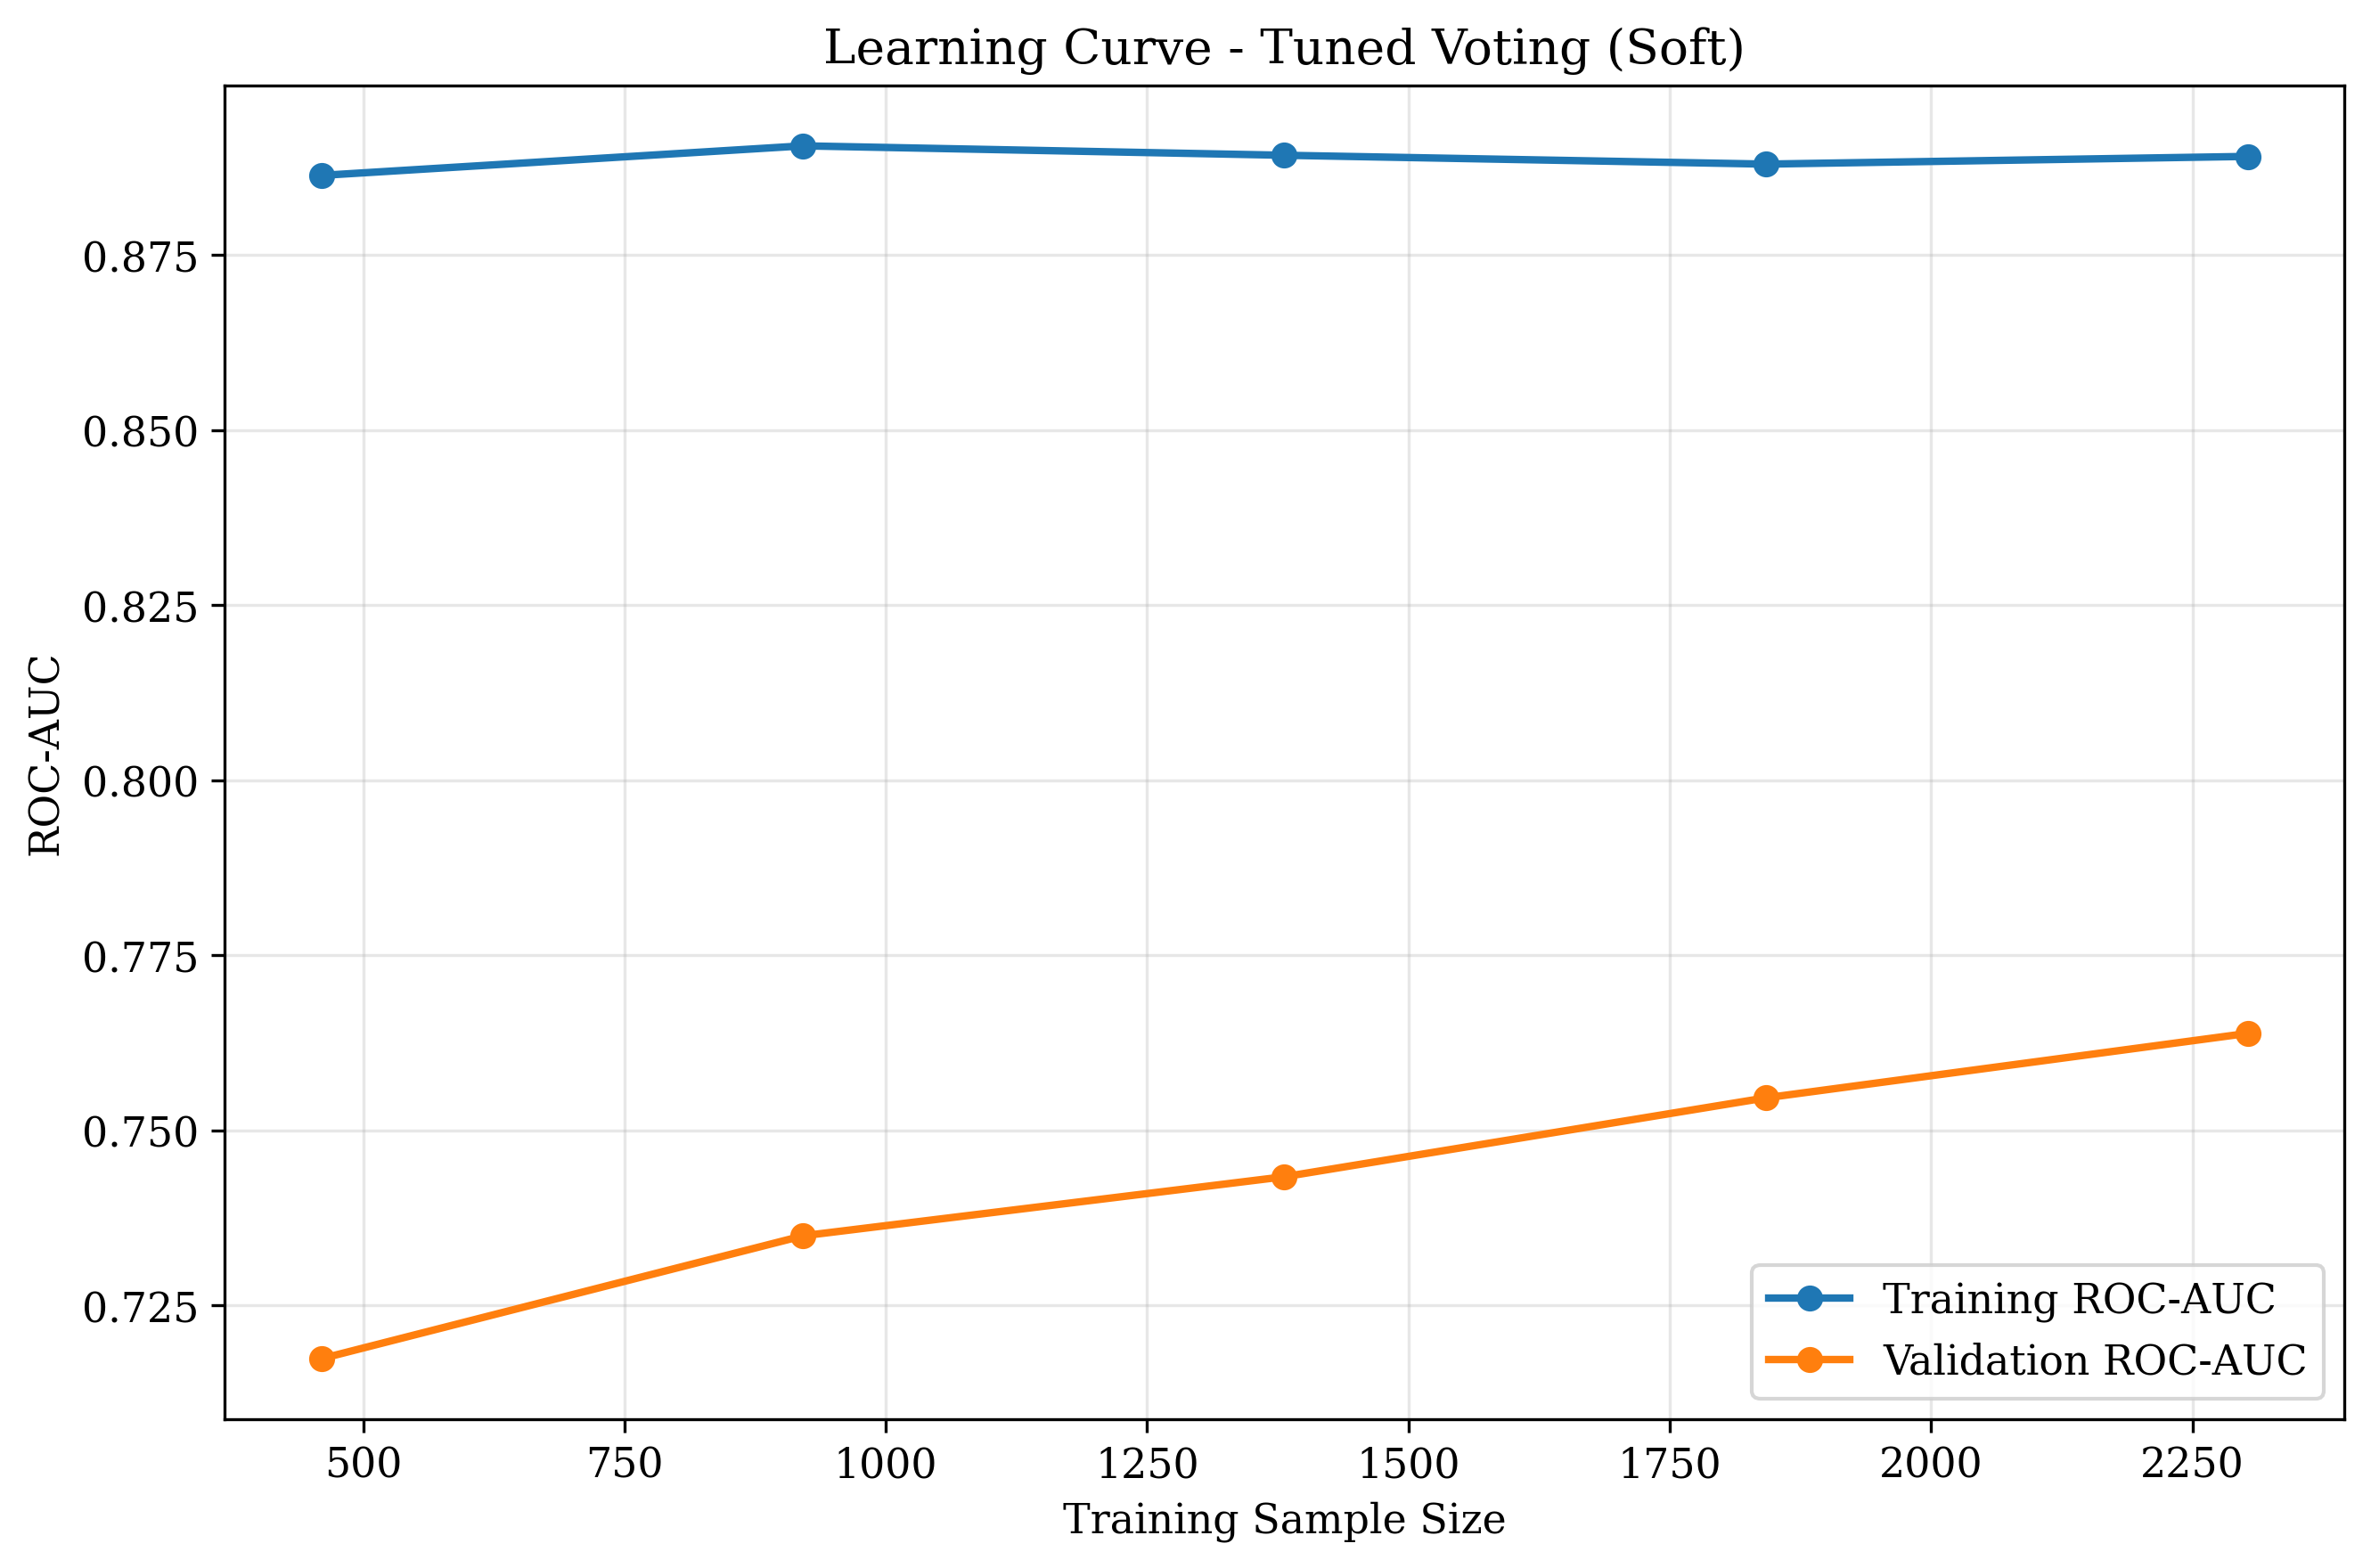

In [27]:
# ============================================================================
# LEARNING CURVE FOR BEST MODEL
# ============================================================================

print("\nLearning Curve")
print("=" * 70)

best_model_for_lc = clone(all_models_dict[best_model_name])
X_train_lc, _ = get_train_test_for_model(best_model_name)

train_sizes, train_scores, valid_scores = learning_curve(
    best_model_for_lc,
    X_train_lc,
    y_train,
    cv=cv_strategy,
    scoring="roc_auc",
    train_sizes=np.linspace(0.2, 1.0, 5),
    n_jobs=-1
)

train_mean = train_scores.mean(axis=1)
valid_mean = valid_scores.mean(axis=1)

plt.figure(figsize=(9, 6))
plt.plot(train_sizes, train_mean, marker="o", linewidth=2, label="Training ROC-AUC")
plt.plot(train_sizes, valid_mean, marker="o", linewidth=2, label="Validation ROC-AUC")
plt.xlabel("Training Sample Size")
plt.ylabel("ROC-AUC")
plt.title(f"Learning Curve - {best_model_name}")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(dissertation_dir / "figures" / "best_model_learning_curve.png", bbox_inches="tight")
plt.show()

In [28]:
# ============================================================================
# FEATURE IMPORTANCE FOR BEST MODEL
# ============================================================================

print("\nFeature Importance for Best Model")
print("=" * 70)

feature_importance_df = None

if hasattr(best_model, "feature_importances_"):
    feature_importance_df = pd.DataFrame({
        "feature": feature_names_clean,
        "importance": best_model.feature_importances_
    }).sort_values("importance", ascending=False)

elif hasattr(best_model, "coef_"):
    coef_values = best_model.coef_[0]
    feature_importance_df = pd.DataFrame({
        "feature": feature_names_clean,
        "coefficient": coef_values,
        "abs_importance": np.abs(coef_values)
    }).sort_values("abs_importance", ascending=False)

if feature_importance_df is not None:
    print("\nTop 20 Most Important Features:")
    print(feature_importance_df.head(20).to_string(index=False))

    feature_importance_df.to_csv(
        dissertation_dir / "tables" / "best_model_feature_importance.csv",
        index=False
    )

    plt.figure(figsize=(10, 8))

    if "importance" in feature_importance_df.columns:
        plot_df = feature_importance_df.head(20).sort_values("importance", ascending=True)
        plt.barh(plot_df["feature"], plot_df["importance"])
        plt.xlabel("Importance Score")
    else:
        plot_df = feature_importance_df.head(20).sort_values("abs_importance", ascending=True)
        plt.barh(plot_df["feature"], plot_df["abs_importance"])
        plt.xlabel("Absolute Coefficient")

    plt.ylabel("Feature")
    plt.title(f"Top 20 Important Features - {best_model_name}")
    plt.tight_layout()
    plt.savefig(
        dissertation_dir / "figures" / "best_model_feature_importance.png",
        bbox_inches="tight"
    )
    plt.show()

    print("\nSaved feature importance table and plot")
else:
    print("Feature importance not directly available for this model.")



Feature Importance for Best Model
Feature importance not directly available for this model.



Permutation Importance for Best Model

Top 20 Permutation Important Features:
                 feature  importance_mean  importance_std
  mother_years_education         0.057036        0.013070
        child_age_months         0.027693        0.007385
                  county         0.026789        0.007164
         wealth_quintile         0.018808        0.005817
         toilet_facility         0.007274        0.002432
mother_currently_working         0.005497        0.001437
  mother_education_level         0.004721        0.002072
   drinking_water_source         0.004693        0.001929
         has_electricity         0.002259        0.001236
               child_sex         0.001914        0.002913
                religion         0.001068        0.001792
       household_members         0.001026        0.002041
            cooking_fuel         0.001007        0.001085
          marital_status         0.000291        0.000570
             urban_rural        -0.000524        0.

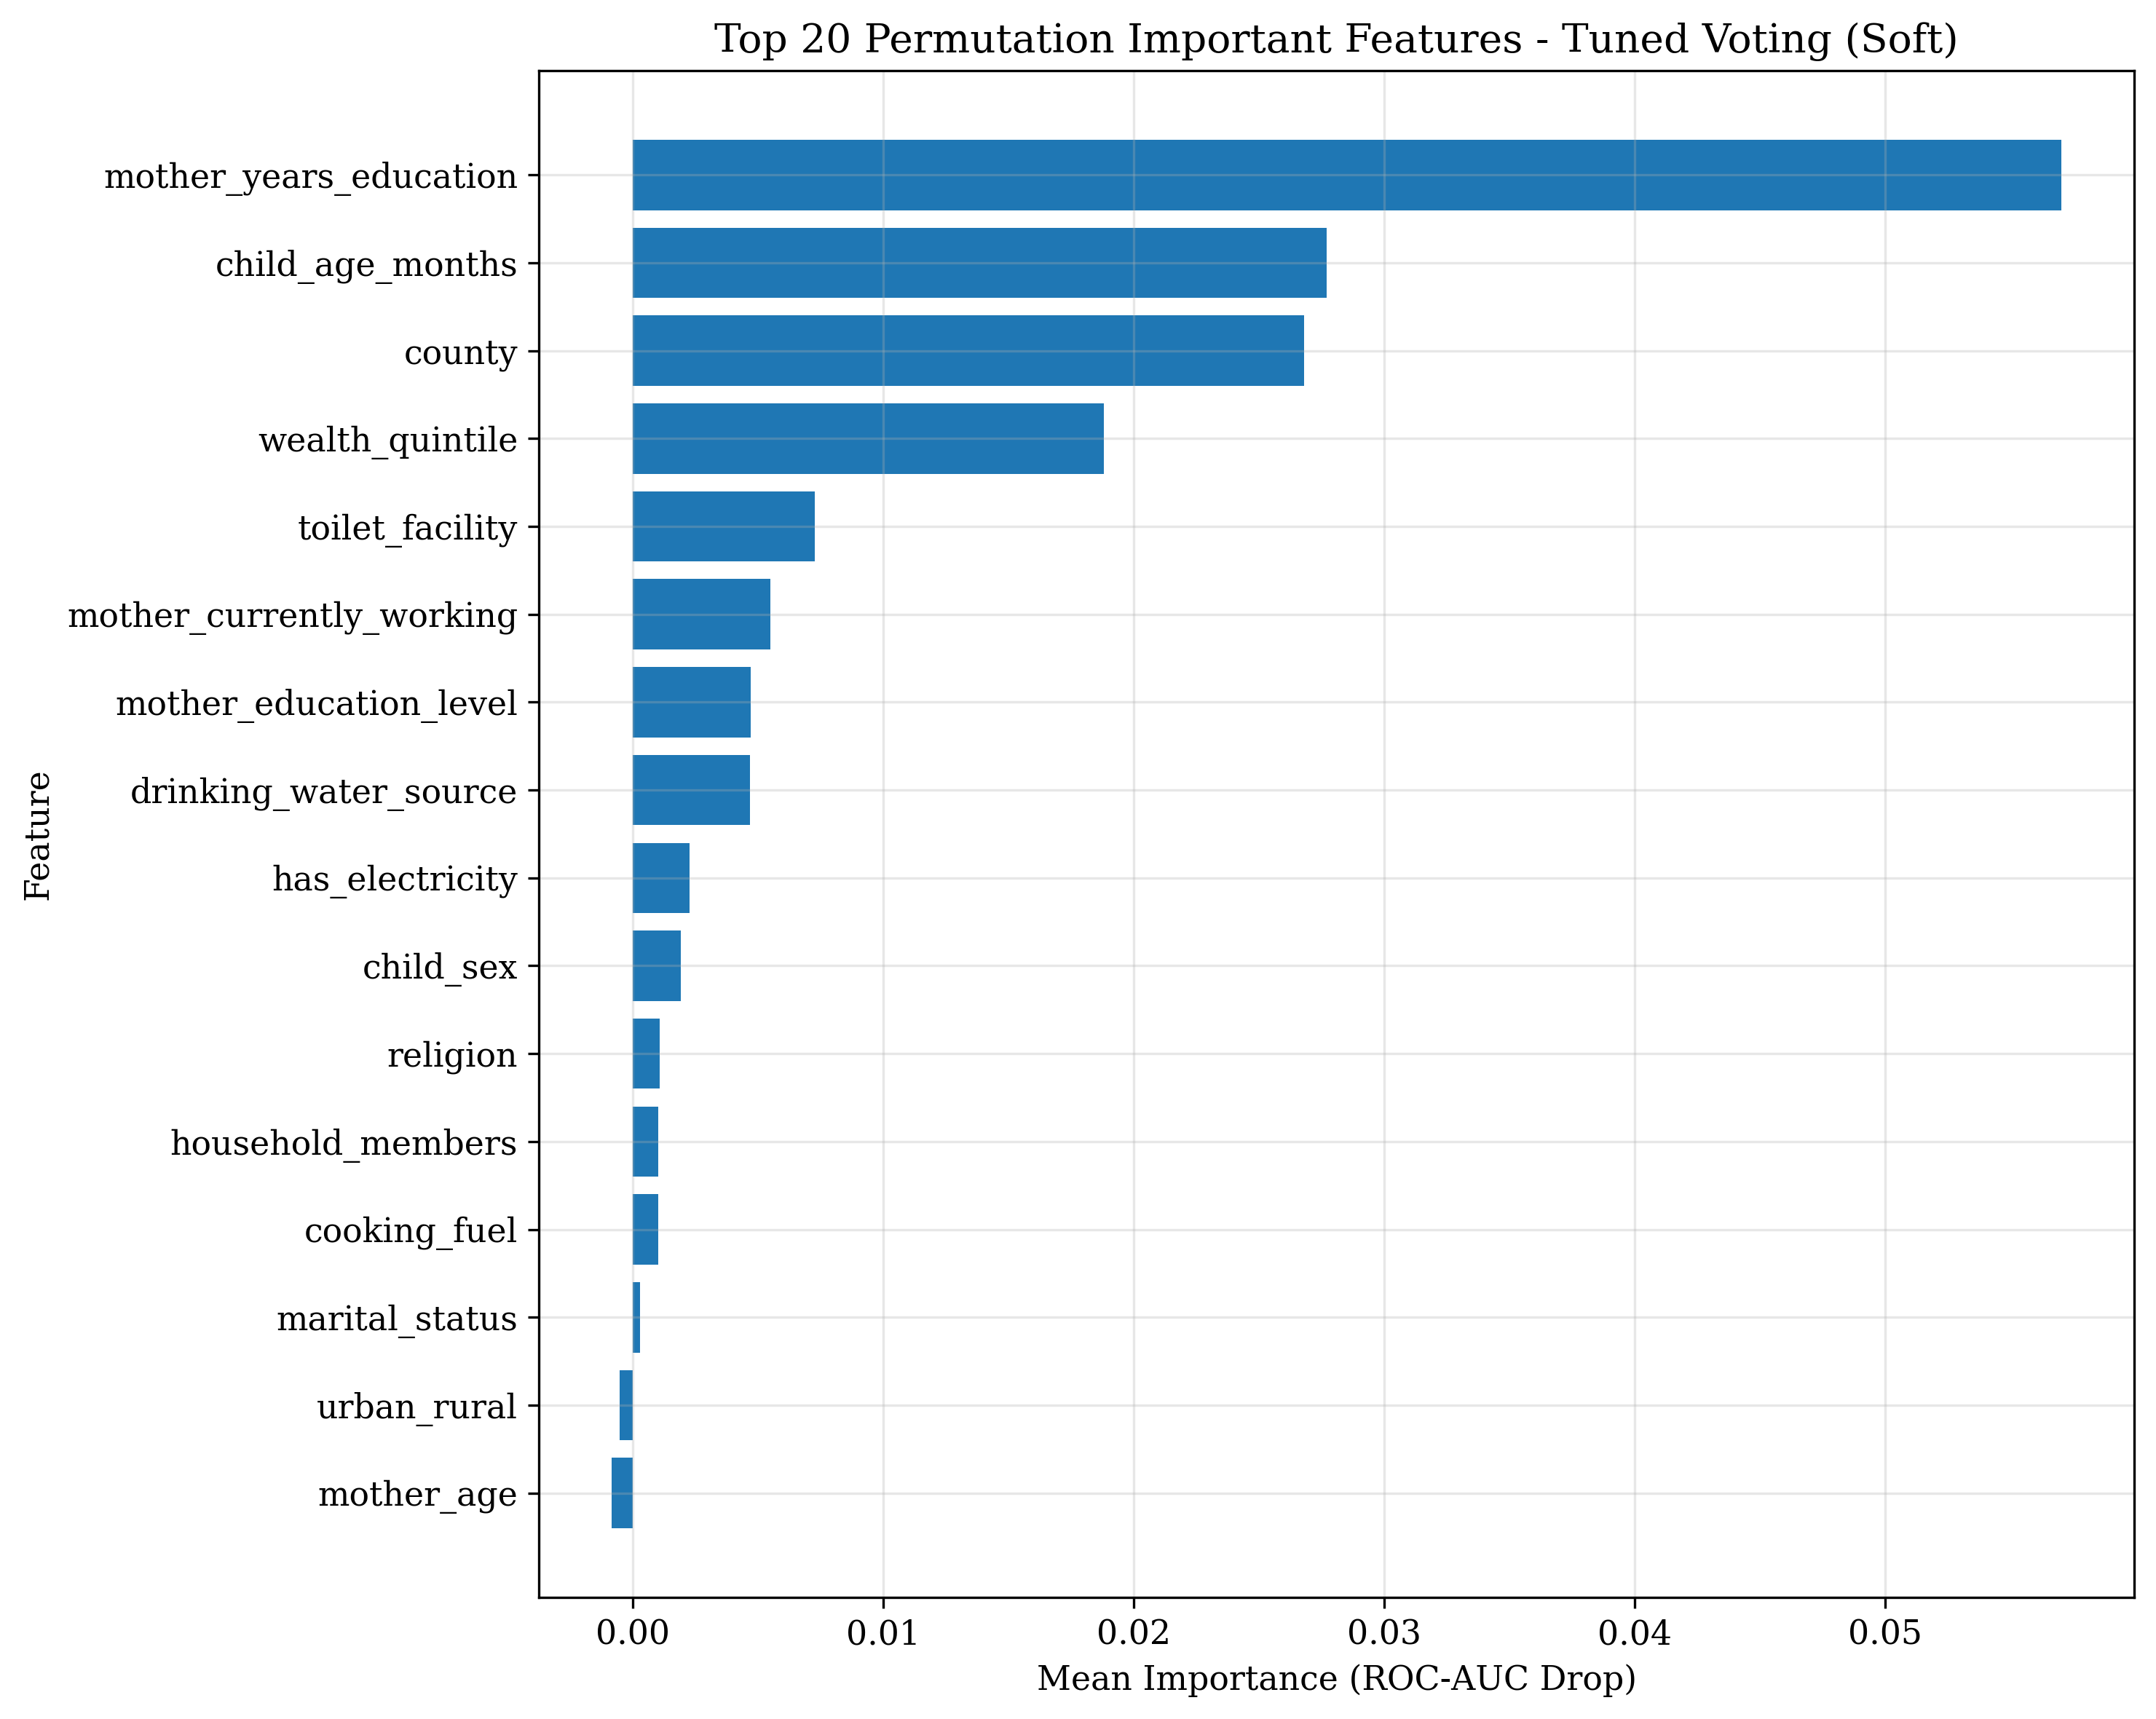

In [29]:
# ============================================================================
# PERMUTATION IMPORTANCE FOR BEST MODEL
# ============================================================================

print("\nPermutation Importance for Best Model")
print("=" * 70)

perm_result = permutation_importance(
    best_model,
    best_model_X_test,
    y_test,
    scoring="roc_auc",
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)

perm_importance_df = pd.DataFrame({
    "feature": feature_names_clean,
    "importance_mean": perm_result.importances_mean,
    "importance_std": perm_result.importances_std
}).sort_values("importance_mean", ascending=False)

print("\nTop 20 Permutation Important Features:")
print(perm_importance_df.head(20).to_string(index=False))

perm_importance_df.to_csv(
    dissertation_dir / "tables" / "best_model_permutation_importance.csv",
    index=False
)

plot_df = perm_importance_df.head(20).sort_values("importance_mean", ascending=True)

plt.figure(figsize=(10, 8))
plt.barh(plot_df["feature"], plot_df["importance_mean"])
plt.xlabel("Mean Importance (ROC-AUC Drop)")
plt.ylabel("Feature")
plt.title(f"Top 20 Permutation Important Features - {best_model_name}")
plt.tight_layout()
plt.savefig(
    dissertation_dir / "figures" / "best_model_permutation_importance.png",
    bbox_inches="tight"
)
plt.show()

In [30]:
# ============================================================================
# CLASSIFICATION REPORT FOR BEST MODEL
# ============================================================================

print("\nClassification Report for Best Model")
print("=" * 70)

y_pred_best = best_model.predict(best_model_X_test)
print(classification_report(y_test, y_pred_best, digits=4))


Classification Report for Best Model
              precision    recall  f1-score   support

           0     0.6950    0.7616    0.7268       365
           1     0.7281    0.6563    0.6904       355

    accuracy                         0.7097       720
   macro avg     0.7116    0.7090    0.7086       720
weighted avg     0.7113    0.7097    0.7088       720



In [31]:
# ============================================================================
# SAVE BEST MODEL FOR FLASK API
# ============================================================================

print("\nSaving Best Model for Flask API")
print("=" * 70)

api_dir = paths["models"] / "api_assets"
api_dir.mkdir(parents=True, exist_ok=True)

final_best_model = clone(all_models_dict[best_model_name])
X_train_best, _ = get_train_test_for_model(best_model_name)
final_best_model.fit(X_train_best, y_train)

joblib.dump(final_best_model, api_dir / "best_model.pkl")

if uses_scaled_features(best_model_name):
    joblib.dump(scaler, api_dir / "feature_scaler.pkl")

with open(api_dir / "feature_names.json", "w") as f:
    json.dump(feature_names_clean, f, indent=2)

best_threshold_value = float(best_threshold_row["threshold"]) if "threshold" in best_threshold_row else 0.50
with open(api_dir / "decision_threshold.json", "w") as f:
    json.dump({"threshold": best_threshold_value}, f, indent=2)

best_model_metadata = {
    "best_model_name": best_model_name,
    "threshold": best_threshold_value,
    "roc_auc": float(final_results_df.loc[best_model_name, "roc_auc"]) if pd.notnull(final_results_df.loc[best_model_name, "roc_auc"]) else None,
    "cv_roc_auc_mean": float(final_results_df.loc[best_model_name, "cv_roc_auc_mean"]) if pd.notnull(final_results_df.loc[best_model_name, "cv_roc_auc_mean"]) else None,
    "f1": float(final_results_df.loc[best_model_name, "f1"]),
    "precision": float(final_results_df.loc[best_model_name, "precision"]),
    "recall": float(final_results_df.loc[best_model_name, "recall"]),
    "accuracy": float(final_results_df.loc[best_model_name, "accuracy"]),
    "saved_at": datetime.now().isoformat()
}

with open(api_dir / "best_model_metadata.json", "w") as f:
    json.dump(best_model_metadata, f, indent=2)

print(f"Saved API assets to: {api_dir}")
print(f"Best model: {best_model_name}")


Saving Best Model for Flask API
Saved API assets to: /Users/collinsbiwott/Desktop/ecd_final_ml/models/api_assets
Best model: Tuned Voting (Soft)


In [32]:
# ============================================================================
# FINAL NOTEBOOK SUMMARY
# ============================================================================

print("\nNotebook 03 Complete")
print("=" * 70)
print(f"Best Model: {best_model_name}")
print(f"Best ROC-AUC: {final_results_df.loc[best_model_name, 'roc_auc']:.4f}")
print(f"Best F1-Score: {final_results_df.loc[best_model_name, 'f1']:.4f}")
print(f"Top 5 Models: {top5_names}")
print(f"Figures saved to: {dissertation_dir / 'figures'}")
print(f"Tables saved to: {tables_dir}")
print(f"API assets saved to: {api_dir}")


Notebook 03 Complete
Best Model: Tuned Voting (Soft)
Best ROC-AUC: 0.7716
Best F1-Score: 0.6904
Top 5 Models: ['Tuned Voting (Soft)', 'Tuned Stacking (LR Meta)', 'Tuned XGBoost', 'Bagging (RF Base)', 'Random Forest']
Figures saved to: /Users/collinsbiwott/Desktop/ecd_final_ml/reports/dissertation/figures
Tables saved to: /Users/collinsbiwott/Desktop/ecd_final_ml/reports/tables
API assets saved to: /Users/collinsbiwott/Desktop/ecd_final_ml/models/api_assets
